In [13]:
import sys
from pathlib import Path
current_dir = Path().resolve()
sys.path.append(current_dir.parent.parent.as_posix())

import os
from os import listdir
from os.path import isfile, join

# %% General setup
import pandas as pd
from pathlib import Path
from data_io import DataIO

import utils
import numpy as np
import plotly
import plotly.graph_objs as go
from utils import make_figure, save_fig
from scipy.stats import wilcoxon
from audrey.preprocessing.project_colors import ProjectColors

# Load data
session_id = '251015'
data_dir = Path(r'/media/aleong/Audrey-experiments/dataset')
figure_dir = data_dir / Path(session_id)

if not os.path.exists(figure_dir):
    os.makedirs(figure_dir)
    print(f"Created the figure folder : {figure_dir}")

data_io = DataIO(data_dir)
loadname = data_dir / f'{session_id}_cells.csv'
data_io.load_session(session_id, load_pickle=False, load_waveforms=False)
data_io.dump_as_pickle()

cells_df = pd.read_csv(loadname, header=[0, 1], index_col=0)
clrs = ProjectColors()

# INCLUDE_RANGE = 50  # include cells at max distance = 50 um

### Select the recordings to analyse

In [14]:
# Print available recording ids
print("Available recording ids:")
for rec_id in data_io.recording_ids:
    print(f"- {rec_id}")


# Manually select recordings to analyse
recording_nrs = [6, 7]

selected_rec_names = []
for r in recording_nrs:
    rec_name = None
    for rec_id in data_io.recording_ids:
        if f'_{r:03d}_' in rec_id:
            rec_name = rec_id
            selected_rec_names.append(rec_name)
            break

print(f"\nSelected recordings:")
for rec_name in selected_rec_names:
    print(f"- {rec_name}")

Available recording ids:
- 251015_A_006_noblocker_pa_prr_series
- 251015_A_007_noblocker_light_pa_series

Selected recordings:
- 251015_A_006_noblocker_pa_prr_series
- 251015_A_007_noblocker_light_pa_series


In [ ]:
# tid = data_io.burst_df.query('duty_cycle == 29 and burst_duration == 10')
# print(tid.train_id.unique())

### Detect the electrode stimulation site with the most significant responses, per cell

In [15]:
# %% Detect electrode stim site with most significant responses, per cell
pref_ec_dict = {}

for cluster_id in data_io.cluster_df.index.values:
    pref_ec = None
    n_sig_pref_ec = None

    max_fr = None
    for ec in data_io.burst_df.electrode.unique():
        if pd.isna(ec):
            continue

        df = data_io.burst_df.query(f'electrode == {float(ec)}')
        tids = df.train_id.unique()
        n_sig = 0
        for tid in tids:
            if cells_df.loc[cluster_id, (tid, 'is_significant')] is True:
                n_sig += 1

        if n_sig > 1:
            if pref_ec is None or n_sig > n_sig_pref_ec:
                pref_ec = ec
                n_sig_pref_ec = n_sig

    pref_ec_dict[cluster_id] = pref_ec


print('Electrode stimulation site with the most significant responses per cell detected.\n\n------ End Of Cell ------')

Electrode stimulation site with the most significant responses per cell detected.

------ End Of Cell ------


In [ ]:
# uid = '_000'
# uid = [u for u in data_io.cluster_df.index.values if uid in u][0]
# ec = pref_ec_dict[uid]

# df = data_io.burst_df.query(f'duty_cycle == 29 and burst_duration == 10 and electrode == {ec}')
# train_ids = df.train_id.unique()
# assert len(train_ids) == 1
# tid = train_ids[0]

# info = cells_df.loc[uid, tid]
# print(info)

# Test WIP Audrey
### Generating a summary dataframe

In [ ]:
''' Test WIP '''
##%% optimized single-panel firing rate plotting
x  = 0
pa_lat = []
light_lat = []

for cluster_id in data_io.cluster_df.index.values:

    # Load data for this cluster
    cluster_data = utils.load_obj(
        data_dir / 'bootstrapped' / f'bootstrap_{cluster_id}.pkl'
    )

    # preferred electrode
    ec = pref_ec_dict[cluster_id]

    if ec is None:
        continue

    # Track global y-limits
    y_max = 0

    # Loop over all recordings (all curves go on same axis)
    for rec_i, rec_name in enumerate(selected_rec_names):

        # Filter data
        d_select = data_io.burst_df.query(
            'electrode == @ec and recording_name == @rec_name'
        ).copy()

        if len(d_select) == 0:
            continue

        d_select.sort_values('duty_cycle', inplace=True)

        # Determine stim type: PA vs PA+light
        #if '_PADMD_' in rec_name:
        if '_light_pa_' in rec_name:
            duty_cycles = d_select.laser_duty_cycle.unique()
            mode = 'light'
        #elif '_PA_' in rec_name:
        elif '_pa_' in rec_name:
            duty_cycles = d_select.duty_cycle.unique()
            mode = 'pa'
        else:
            continue

        for dc in duty_cycles:
            # Extract train ID + burst settings
            row0    = d_select.query('laser_duty_cycle == @dc').iloc[0]
            tid     = row0.train_id
            lat     = cells_df.xs(cluster_id)[tid, 'response_latency']
            repfr   = cells_df.xs(cluster_id)[tid, 'response_firing_rate']
            reptype = cells_df.xs(cluster_id)[tid, 'response_type']

            if not np.isnan(lat) :
                if mode == 'light':
                    light_lat.append([cluster_id, ec, dc, lat, repfr, reptype])

                elif mode == 'pa':
                    pa_lat.append([cluster_id, ec, dc, lat, repfr, reptype])

# Summary df for pa responses
df_pa_lat = pd.DataFrame(pa_lat, columns=['cluster_id', 'pref_ec', 'dc', 'pa_response_latency', 'pa_rep_fr','pa_rep_type'])
df_pa_lat.set_index(['cluster_id', 'pref_ec','dc'], inplace = True)

# Summary df for light + pa responses
df_light_lat = pd.DataFrame(light_lat, columns=['cluster_id', 'pref_ec', 'dc', 'light_response_latency', 'light_rep_fr','light_rep_type'])
df_light_lat.set_index(['cluster_id', 'pref_ec','dc'], inplace = True)

# Summary df
lat_df = pd.concat([df_pa_lat, df_light_lat], axis = 1, join = 'outer')

print("\n\nAll clusters processed.\nSummary df generated.\n\t\t\t------ End Of Cell ------")


### Plot PA vs light responses

In [ ]:
df = lat_df.reset_index()

dc_values = sorted(df["dc"].unique())

# Remove dc = 37
df = df[df["dc"] != 37]

dc_values = sorted(df["dc"].unique())
clusters = sorted(df["cluster_id"].unique())

# -------------------
# Figure layout
# -------------------
n_cols = 2
n_rows = int(np.ceil(len(dc_values) / n_cols))

subplot_titles = {
    r + 1: [f"DC = {dc_values[r*n_cols + c]}" if r*n_cols + c < len(dc_values) else ""
            for c in range(n_cols)]
    for r in range(n_rows)
}

fig = utils.simple_fig(
    n_cols=n_cols,
    n_rows=n_rows,
    width=1.4,
    height=0.9 * n_rows,
    subplot_titles=subplot_titles,
    # equal_width_height="x",   # enforce square panels
)

# -------------------
# Axis limits (shared origin at 0)
# -------------------
max_val = max(
    df["pa_response_latency"].max(),
    df["light_response_latency"].max()
)

axis_min = 0
axis_max = max_val * 1.05

# First axes explicitly
fig.update_layout(
    xaxis=dict(range=[axis_min, axis_max]),
    yaxis=dict(range=[axis_min, axis_max], scaleanchor="x", scaleratio=1),
)

# Match all others
fig.update_xaxes(matches="x")
fig.update_yaxes(matches="y", scaleanchor="x", scaleratio=1)

# -------------------
# Plotting
# -------------------
for i, dc in enumerate(dc_values):
    row = i // n_cols + 1
    col = i % n_cols + 1

    sub = df[df["dc"] == dc]

    # per-cluster scatter
    for ci, cluster_id in enumerate(clusters):
        cd = sub[sub["cluster_id"] == cluster_id]
        if cd.empty:
            continue

        color = utils.interp_color(len(clusters), ci, ("qualitative", "Plotly"), alpha=0.9)

        fig.add_trace(
            go.Scatter(
                x=cd["pa_response_latency"],
                y=cd["light_response_latency"],
                mode="markers",
                marker=dict(color=color, size=5),
                name=f"cluster {cluster_id}",
                legendgroup=str(cluster_id),
                showlegend=(i == 0),
            ),
            row=row,
            col=col,
        )

    # identity line
    fig.add_trace(
        go.Scatter(
            x=[axis_min, axis_max],
            y=[axis_min, axis_max],
            mode="lines",
            line=dict(color="black", dash="dash", width=1),
            showlegend=False,
        ),
        row=row,
        col=col,
    )

# -------------------
# Axis labels
# -------------------
fig.update_xaxes(tickmode="auto", showticklabels=True, title_text="PA response latency")
fig.update_yaxes(tickmode="auto", showticklabels=True, title_text="PA + Light response latency")

fig.update_layout(
    xaxis=dict(range=[0, axis_max], zeroline=True),
    yaxis=dict(range=[0, axis_max], scaleanchor="x"),
)

# Match all others
fig.update_xaxes(matches="x")
fig.update_yaxes(matches="y", scaleanchor="x", scaleratio=1)

fig.show()
# sname = figure_dir / f'{session_id}_test_5v9'
# save_fig(fig, sname, formats=['png', 'svg'], scale=3)

In [ ]:
df = lat_df.reset_index()

dc_values = sorted(df["dc"].unique())

if len(dc_values) == 0:
    raise ValueError(
        "No data left after filtering by rep_case. "
        "Check pa_rep_type / light_rep_type values in the CSV."
    )

# Remove dc = 37
df = df[df["dc"] != 37]

# -----------------------
# Define case categories
# -----------------------
def normalize(v):
    if pd.isna(v):
        return "nan"
    return str(v).lower()

def rep_case(row):
    pa = normalize(row["pa_rep_type"])
    li = normalize(row["light_rep_type"])
    return f"{pa}|{li}"

df["rep_case"] = df.apply(rep_case, axis=1)

case_labels = {
    "inhibited|inhibited": "PA inh / Light inh",
    "inhibited|excited":   "PA inh / Light exc",
    "inhibited|nan":       "PA inh / Light nan",
    "excited|inhibited":   "PA exc / Light inh",
    "excited|excited":     "PA exc / Light exc",
    "excited|nan":         "PA exc / Light nan",
    "nan|inhibited":       "PA nan / Light inh",
    "nan|excited":         "PA nan / Light exc",
}

df = df[df["rep_case"].isin(case_labels.keys())]

cases = list(case_labels.keys())

# -----------------------
# Subplot layout
# -----------------------
dc_values = sorted(df["dc"].unique())
n_cols = 2
n_rows = int(np.ceil(len(dc_values) / n_cols))

subplot_titles = {
    r + 1: [
        f"DC = {dc_values[r*n_cols + c]}" if r*n_cols + c < len(dc_values) else ""
        for c in range(n_cols)
    ]
    for r in range(n_rows)
}

fig = utils.simple_fig(
    n_cols=n_cols,
    n_rows=n_rows,
    width=1.4,
    height=0.9 * n_rows,
    subplot_titles=subplot_titles,
)

# -----------------------
# Axis limits (shared)
# -----------------------
max_val = max(
    df["pa_response_latency"].max(),
    df["light_response_latency"].max()
)

axis_min = 0
axis_max = max_val * 1.05

fig.update_layout(
    xaxis=dict(range=[axis_min, axis_max], zeroline=True),
    yaxis=dict(range=[axis_min, axis_max], scaleanchor="x", scaleratio=1, zeroline=True),
)

fig.update_xaxes(matches="x", tickmode="auto", showticklabels=True)
fig.update_yaxes(matches="y", scaleanchor="x", scaleratio=1, tickmode="auto", showticklabels=True)

# -----------------------
# Colors for cases
# -----------------------
case_colors = {}
for i, case in enumerate(cases):
    case_colors[case] = utils.interp_color(
        nsteps=len(cases),
        step_nr=i,
        scalename=("qualitative", "Plotly"),
        alpha=0.9
    )

# -----------------------
# Plot
# -----------------------
for i, dc in enumerate(dc_values):
    row = i // n_cols + 1
    col = i % n_cols + 1

    sub = df[df["dc"] == dc]

    for case in cases:
        cd = sub[sub["rep_case"] == case]
        if cd.empty:
            continue

        fig.add_trace(
            go.Scatter(
                x=cd["pa_response_latency"],
                y=cd["light_response_latency"],
                mode="markers",
                marker=dict(color=case_colors[case], size=5),
                name=case_labels[case],
                legendgroup=case,
                showlegend=(i == 0),
                hovertemplate=(
                    "PA: %{x}<br>"
                    "Light: %{y}<br>"
                    f"{case_labels[case]}<extra></extra>"
                ),
            ),
            row=row,
            col=col,
        )

    # Identity line
    fig.add_trace(
        go.Scatter(
            x=[axis_min, axis_max],
            y=[axis_min, axis_max],
            mode="lines",
            line=dict(color="black", dash="dash", width=1),
            showlegend=False,
        ),
        row=row,
        col=col,
    )

# Axis labels
fig.update_xaxes(title_text="PA response latency (ms)")
fig.update_yaxes(title_text="PA + Light response latency (ms)")

fig.show()
sname = figure_dir / f'{session_id}_rep_latency'
save_fig(fig, sname, formats=['png'], scale=3)


In [ ]:
df = lat_df.reset_index()

dc_values = sorted(df["dc"].unique())

if len(dc_values) == 0:
    raise ValueError(
        "No data left after filtering by rep_case. "
        "Check pa_rep_type / light_rep_type values in the CSV."
    )

# Remove dc = 37
df = df[df["dc"] != 37]

# -----------------------
# Define case categories
# -----------------------
def normalize(v):
    if pd.isna(v):
        return "nan"
    return str(v).lower()

def rep_case(row):
    pa = normalize(row["pa_rep_type"])
    li = normalize(row["light_rep_type"])
    return f"{pa}|{li}"

df["rep_case"] = df.apply(rep_case, axis=1)

case_labels = {
    "inhibited|inhibited": "PA inh / Light inh",
    "inhibited|excited":   "PA inh / Light exc",
    "inhibited|nan":       "PA inh / Light nan",
    "excited|inhibited":   "PA exc / Light inh",
    "excited|excited":     "PA exc / Light exc",
    "excited|nan":         "PA exc / Light nan",
    "nan|inhibited":       "PA nan / Light inh",
    "nan|excited":         "PA nan / Light exc",
}

df = df[df["rep_case"].isin(case_labels.keys())]

cases = list(case_labels.keys())

# -----------------------
# Subplot layout
# -----------------------
dc_values = sorted(df["dc"].unique())
n_cols = 2
n_rows = int(np.ceil(len(dc_values) / n_cols))

subplot_titles = {
    r + 1: [
        f"DC = {dc_values[r*n_cols + c]}" if r*n_cols + c < len(dc_values) else ""
        for c in range(n_cols)
    ]
    for r in range(n_rows)
}

fig = utils.simple_fig(
    n_cols=n_cols,
    n_rows=n_rows,
    width=1.4,
    height=0.9 * n_rows,
    subplot_titles=subplot_titles,
)

# -----------------------
# Axis limits (shared)
# -----------------------
max_val = max(
    df["pa_rep_fr"].max(),
    df["light_rep_fr"].max()
)

axis_min = 0
axis_max = max_val * 1.05

fig.update_layout(
    xaxis=dict(range=[axis_min, axis_max], zeroline=True),
    yaxis=dict(range=[axis_min, axis_max], scaleanchor="x", scaleratio=1, zeroline=True),
)

fig.update_xaxes(matches="x", tickmode="auto", showticklabels=True)
fig.update_yaxes(matches="y", scaleanchor="x", scaleratio=1, tickmode="auto", showticklabels=True)

# -----------------------
# Colors for cases
# -----------------------
case_colors = {}
for i, case in enumerate(cases):
    case_colors[case] = utils.interp_color(
        nsteps=len(cases),
        step_nr=i,
        scalename=("qualitative", "Plotly"),
        alpha=0.9
    )

# -----------------------
# Plot
# -----------------------
for i, dc in enumerate(dc_values):
    row = i // n_cols + 1
    col = i % n_cols + 1

    sub = df[df["dc"] == dc]

    for case in cases:
        cd = sub[sub["rep_case"] == case]
        if cd.empty:
            continue

        fig.add_trace(
            go.Scatter(
                x=cd["pa_rep_fr"],
                y=cd["light_rep_fr"],
                mode="markers",
                marker=dict(color=case_colors[case], size=5),
                name=case_labels[case],
                legendgroup=case,
                showlegend=(i == 0),
                hovertemplate=(
                    "PA: %{x}<br>"
                    "Light: %{y}<br>"
                    f"{case_labels[case]}<extra></extra>"
                ),
            ),
            row=row,
            col=col,
        )

    # Identity line
    fig.add_trace(
        go.Scatter(
            x=[axis_min, axis_max],
            y=[axis_min, axis_max],
            mode="lines",
            line=dict(color="black", dash="dash", width=1),
            showlegend=False,
        ),
        row=row,
        col=col,
    )

# Axis labels
fig.update_xaxes(title_text="PA response firing rate (Hz)")
fig.update_yaxes(title_text="PA + Light response firing rate (Hz)")

fig.show()
sname = figure_dir / f'{session_id}_firing_rate'
save_fig(fig, sname, formats=['png'], scale=3)


# PSTH tests

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from typing import Dict, Any

# ============================================================
# Parameters (ms) – MATCH raster time axis
# ============================================================

BIN_SIZE_MS = 2.0
PRE_TIME_MS = 500.0     # same as raster
POST_TIME_MS = 500.0    # same as raster
SMOOTH_SIGMA = 1.0

INHIB_K_SD = 2.0
EXCIT_K_SD = 2.0
MIN_DURATION_MS = 20.0

# ============================================================
# Time bins
# ============================================================

t_edges = np.arange(-PRE_TIME_MS, POST_TIME_MS + BIN_SIZE_MS, BIN_SIZE_MS)
t_centers = t_edges[:-1] + BIN_SIZE_MS / 2
n_bins = len(t_centers)

# ============================================================
# Helper functions
# ============================================================

def detect_latency(rate_smooth, mu, sd):
    """
    Inhibitory detection is prioritized over excitatory.
    Returns: (response_type, latency_ms)
    """

    min_bins = max(1, int(np.round(MIN_DURATION_MS / BIN_SIZE_MS)))

    inhib_thresh = mu - INHIB_K_SD * sd
    excit_thresh = mu + EXCIT_K_SD * sd

    search_mask = (t_centers >= 0) & (t_centers <= POST_TIME_MS)
    idxs = np.where(search_mask)[0]

    below = rate_smooth < inhib_thresh
    above = rate_smooth > excit_thresh

    inhib_latency = np.nan
    excit_latency = np.nan

    # ---- inhibitory FIRST ----
    for i in idxs:
        if below[i] and np.all(below[i:i + min_bins]):
            inhib_latency = t_centers[i]
            break

    # ---- excitatory SECOND ----
    for i in idxs:
        if above[i] and np.all(above[i:i + min_bins]):
            excit_latency = t_centers[i]
            break

    if not np.isnan(inhib_latency):
        return "inhibitory", inhib_latency

    if not np.isnan(excit_latency):
        return "excitatory", excit_latency

    return "none", np.nan


def get_stim_color(idx, total, stim_type):
    """
    stim_type: 'PA' or 'PA+light'
    """
    if stim_type == "PA":
        cmap = plt.cm.Greens
    else:
        cmap = plt.cm.Purples

    if total <= 1:
        return cmap(0.7)

    return cmap(0.3 + 0.6 * idx / (total - 1))


# ============================================================
# Main analysis (cluster-first)
# ============================================================

cluster_ids = data_io.cluster_df.index.values
output_data: Dict[int, Dict[int, Dict[str, Any]]] = {}

for cluster_id in cluster_ids:

    print(f"PSTH overlay for cluster {cluster_id}")

    ec = pref_ec_dict.get(cluster_id)
    if ec is None:
        continue

    output_data[cluster_id] = {}

    fig, ax = plt.subplots(figsize=(10, 5))
    has_any = False

    pa_stims = []
    palight_stims = []

    # ---------- collect stims first ----------
    for rec_name in selected_rec_names:

        d_select = data_io.burst_df.query(
            'electrode == @ec and recording_name == @rec_name'
        ).copy()

        if d_select.empty:
            continue

        if '_light_pa_' in rec_name:
            for dc in d_select.laser_duty_cycle.unique():
                tid = d_select.query('laser_duty_cycle == @dc').iloc[0].train_id
                palight_stims.append((rec_name, dc, tid))
        elif '_pa_' in rec_name:
            for dc in d_select.duty_cycle.unique():
                tid = d_select.query('duty_cycle == @dc').iloc[0].train_id
                pa_stims.append((rec_name, dc, tid))

    # ---------- process PA ----------
    for idx, (rec_name, dc, tid) in enumerate(pa_stims):

        frep = data_io.burst_df.query('train_id == @tid').iloc[0].duty_cycle
        bd = data_io.burst_df.query('train_id == @tid').iloc[0].burst_duration
        rec_id = str(data_io.burst_df.query('train_id == @tid').iloc[0].rec_id)

        burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values \
            if data_io.burst_df.query('train_id == @tid').iloc[0].stimtype in ('laser', 'padmd') \
            else data_io.burst_df.query('train_id == @tid').dmd_burst_onset.values

        spiketrain = data_io.spiketimes[rec_id][cluster_id]

        binned_sp = np.zeros((len(burst_onsets), n_bins), dtype=int)
        spike_times = []

        for i, onset in enumerate(burst_onsets):
            idxs = np.where((spiketrain >= onset + t_edges[0]) &
                            (spiketrain < onset + t_edges[-1]))[0]
            rel_spikes = spiketrain[idxs] - onset
            spike_times.append(rel_spikes)
            binned_sp[i], _ = np.histogram(rel_spikes, bins=t_edges)

        if len(spike_times) == 0:
            continue

        rate = binned_sp.sum(axis=0) / (len(spike_times) * (BIN_SIZE_MS / 1000))
        rate_smooth = gaussian_filter1d(rate, SMOOTH_SD)

        baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
        mu = rate_smooth[baseline_mask].mean()
        sd = rate_smooth[baseline_mask].std(ddof=1)

        resp_type, latency_ms = detect_latency(rate_smooth, mu, sd)

        output_data[cluster_id][tid] = dict(
            bins=t_centers,
            spike_times=spike_times,
            firing_rate=rate,
            firing_rate_smooth=rate_smooth,
            baseline_mean=mu,
            baseline_sd=sd,
            response_type=resp_type,
            latency_ms=latency_ms,
        )

        color = get_stim_color(idx, len(pa_stims), "PA")
        label = f"PA dc={frep:.0f} bd={bd:.0f}"

        ax.plot(t_centers, rate_smooth, color=color, lw=2, label=label)

        if resp_type == "excitatory":
            ax.axvline(latency_ms, color=color, ls='--', lw=1.5)
        elif resp_type == "inhibitory":
            ax.axvline(latency_ms, color=color, ls=':', lw=1.5)

        has_any = True

    # ---------- process PA+light ----------
    for idx, (rec_name, dc, tid) in enumerate(palight_stims):

        frep = data_io.burst_df.query('train_id == @tid').iloc[0].laser_duty_cycle
        bd = data_io.burst_df.query('train_id == @tid').iloc[0].laser_burst_duration
        rec_id = str(data_io.burst_df.query('train_id == @tid').iloc[0].rec_id)

        burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values

        spiketrain = data_io.spiketimes[rec_id][cluster_id]

        binned_sp = np.zeros((len(burst_onsets), n_bins), dtype=int)
        spike_times = []

        for i, onset in enumerate(burst_onsets):
            idxs = np.where((spiketrain >= onset + t_edges[0]) &
                            (spiketrain < onset + t_edges[-1]))[0]
            rel_spikes = spiketrain[idxs] - onset
            spike_times.append(rel_spikes)
            binned_sp[i], _ = np.histogram(rel_spikes, bins=t_edges)

        if len(spike_times) == 0:
            continue

        rate = binned_sp.sum(axis=0) / (len(spike_times) * (BIN_SIZE_MS / 1000))
        rate_smooth = gaussian_filter1d(rate, SMOOTH_SD)

        baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
        mu = rate_smooth[baseline_mask].mean()
        sd = rate_smooth[baseline_mask].std(ddof=1)

        resp_type, latency_ms = detect_latency(rate_smooth, mu, sd)

        response_window = (t_centers >= 0) & (t_centers <= 100)
        response_rate = rate_smooth[response_window].mean()

        output_data[cluster_id][tid] = dict(
            bins=t_centers,
            spike_times=spike_times,
            firing_rate=rate,
            firing_rate_smooth=rate_smooth,
            baseline_mean=mu,
            baseline_sd=sd,
            response_type=resp_type,
            latency_ms=latency_ms,
            response_rate=response_rate,
            stim="PA" or "PA+light",
            dc=frep
        )

        color = get_stim_color(idx, len(palight_stims), "PA+light")
        label = f"PA+light dc={frep:.0f} bd={bd:.0f}"

        ax.plot(t_centers, rate_smooth, color=color, lw=2, label=label)

        if resp_type == "excitatory":
            ax.axvline(latency_ms, color=color, ls='--', lw=1.5)
        elif resp_type == "inhibitory":
            ax.axvline(latency_ms, color=color, ls=':', lw=1.5)

        has_any = True



    if not has_any:
        plt.close(fig)
        continue

    ax.axvline(0, color='k', ls='--', alpha=0.6)
    ax.set_xlim([-200, 500])
    ax.set_xlabel("Time (ms)")
    ax.set_ylabel("Firing rate (Hz)")
    ax.set_title(f"Cluster {cluster_id} – PSTH overlay")
    ax.legend(fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()

print("Finished PSTH overlay analysis.")


PSTH overlay for cluster uid_251015_001
PSTH overlay for cluster uid_251015_005
PSTH overlay for cluster uid_251015_011
PSTH overlay for cluster uid_251015_014
PSTH overlay for cluster uid_251015_015
PSTH overlay for cluster uid_251015_018
PSTH overlay for cluster uid_251015_021
PSTH overlay for cluster uid_251015_024
PSTH overlay for cluster uid_251015_027
PSTH overlay for cluster uid_251015_029
PSTH overlay for cluster uid_251015_030
PSTH overlay for cluster uid_251015_041
PSTH overlay for cluster uid_251015_048
PSTH overlay for cluster uid_251015_050
PSTH overlay for cluster uid_251015_052
PSTH overlay for cluster uid_251015_053
PSTH overlay for cluster uid_251015_054
PSTH overlay for cluster uid_251015_057
PSTH overlay for cluster uid_251015_058
PSTH overlay for cluster uid_251015_071
PSTH overlay for cluster uid_251015_072
PSTH overlay for cluster uid_251015_075
PSTH overlay for cluster uid_251015_077
PSTH overlay for cluster uid_251015_083
PSTH overlay for cluster uid_251015_087


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import to_rgb


# ============================================================
# PARAMETERS
# ============================================================
### TOP
BIN_SIZE_MS = 0.5
PRE_TIME_MS = 200.0
POST_TIME_MS = 500.0

# ADAPTIVE SMOOTHING: Higher smoothing for lower baseline rates
# This prevents noise from causing false inhibition detection in low-firing cells
def get_adaptive_smooth_sd(baseline_rate):
    """
    Calculate appropriate smoothing based on baseline firing rate.
    Low firing rates need more smoothing to reduce noise.
    
    Parameters
    ----------
    baseline_rate : float
        Baseline firing rate in Hz
    
    Returns
    -------
    smooth_sd : float
        Smoothing sigma in bins
    """
    if baseline_rate < 3.0:
        # Low firing rate: use heavy smoothing to reduce noise
        return 5.0  # ~2.5 ms smoothing
    elif baseline_rate < 10.0:
        # Medium firing rate: moderate smoothing
        return 3.0  # ~1.5 ms smoothing
    else:
        # High firing rate: light smoothing preserves temporal precision
        return 2.0  # ~1.0 ms smoothing

# Different duration requirements for excitation vs inhibition
MIN_DURATION_EXCIT_MS = 10.0
MIN_DURATION_INHIB_MS = 30.0

# IMPORTANT: Minimum latency - ignore responses before this time
# This prevents detecting "inhibition" that is just low baseline activity
MIN_LATENCY_MS = 10.0  # Start detection 10 ms after stimulus onset

# Parameters for the 3 methods
K_SD_EXCIT = 2.0
K_SD_INHIB = 2.0
INHIB_PERCENT_DROP = 30  # For method 2 (percentage-based)
INHIB_PERCENTILE = 5  # For method 4 (percentile-based)

MIN_INHIB_THRESHOLD = 0.5  # Minimum floor for inhibitory thresholds
MIN_BASELINE_HZ = 1.0

# Choose which method to use for the main analysis
# 1 = SD-based, 2 = Percentage-based, 4 = Percentile-based
PRIMARY_METHOD = 1  # Change this to switch methods

# ============================================================
# TIME AXIS
# ============================================================

t_edges = np.arange(-PRE_TIME_MS, POST_TIME_MS + BIN_SIZE_MS, BIN_SIZE_MS)
t_centers = t_edges[:-1] + BIN_SIZE_MS / 2

# ============================================================
# COLOR UTIL
# ============================================================

def generate_shades(base_color, n):
    """Generate n shades of a base color from dark to light."""
    base = np.array(to_rgb(base_color))
    shades = []
    for i in range(n):
        factor = 0.5 + 0.5 * (i / max(1, n-1))
        shades.append(base * factor + (1-factor))
    return shades

# ============================================================
# LATENCY DETECTION - ALL 3 METHODS
# ============================================================

def calculate_thresholds_all_methods(rate_smooth, mu, sd):
    """Calculate inhibitory thresholds for methods 1, 2, and 4."""
    
    baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
    baseline_values = rate_smooth[baseline_mask]
    
    thresholds = {}
    
    # Method 1: SD-based
    thresholds[1] = {
        'name': 'SD-based',
        'inhib': max(MIN_INHIB_THRESHOLD, mu - K_SD_INHIB * sd),
        'excit': mu + K_SD_EXCIT * sd
    }
    
    # Method 2: Percentage-based
    thresholds[2] = {
        'name': 'Percentage-based',
        'inhib': max(MIN_INHIB_THRESHOLD, mu * (1 - INHIB_PERCENT_DROP/100)),
        'excit': mu + K_SD_EXCIT * sd
    }
    
    # Method 4: Percentile-based
    thresholds[4] = {
        'name': 'Percentile-based',
        'inhib': max(MIN_INHIB_THRESHOLD, np.percentile(baseline_values, INHIB_PERCENTILE)),
        'excit': mu + K_SD_EXCIT * sd
    }
    
    return thresholds

def detect_latency_with_method(rate_smooth, inhib_thresh, excit_thresh, mu):
    """
    Detect latency with given thresholds.
    Uses different duration requirements for excitation vs inhibition.
    Enforces minimum latency to avoid detecting pre-existing low activity as inhibition.
    
    CRITICAL RULE: Cells with baseline < 5 Hz cannot be classified as inhibitory
    - Low baseline rates have too much noise to reliably detect inhibition
    - Apparent "inhibition" is likely just noise fluctuations
    """
    min_bins_inhib = max(1, int(np.round(MIN_DURATION_INHIB_MS / BIN_SIZE_MS)))
    min_bins_excit = max(1, int(np.round(MIN_DURATION_EXCIT_MS / BIN_SIZE_MS)))
    
    # Search starting from MIN_LATENCY_MS to avoid pre-existing low activity
    search_mask = (t_centers >= MIN_LATENCY_MS) & (t_centers <= POST_TIME_MS)
    idxs = np.where(search_mask)[0]
    
    below = rate_smooth < inhib_thresh
    above = rate_smooth > excit_thresh
    
    # Detect latencies
    inh_lat = None
    exc_lat = None
    
    # Inhibitory: requires longer sustained response
    # CRITICAL: Only detect if baseline >= 5 Hz
    if mu >= MIN_MU:
        for i in idxs:
            if i + min_bins_inhib > len(below):
                break
            if below[i] and np.all(below[i:i+min_bins_inhib]):
                inh_lat = t_centers[i]
                break
    
    # Excitatory: allows shorter transient response
    for i in idxs:
        if i + min_bins_excit > len(above):
            break
        if above[i] and np.all(above[i:i+min_bins_excit]):
            exc_lat = t_centers[i]
            break
    
    # Determine response type
    if inh_lat is None and exc_lat is None:
        return "none", np.nan
    elif exc_lat is None:
        return "inhibitory", inh_lat
    elif inh_lat is None:
        return "excitatory", exc_lat
    elif inh_lat < exc_lat:
        return "inhibitory", inh_lat
    else:
        return "excitatory", exc_lat

def detect_latency_all_methods(rate_smooth, mu, sd):
    """
    Detect latency using all 3 methods and return results.
    
    Returns
    -------
    dict with keys 1, 2, 4, each containing:
        - resp_type: str
        - latency_ms: float
        - inhib_thresh: float
        - excit_thresh: float
    """
    thresholds = calculate_thresholds_all_methods(rate_smooth, mu, sd)
    results = {}
    
    for method_id in [1, 2, 4]:
        thresh = thresholds[method_id]
        resp_type, latency = detect_latency_with_method(
            rate_smooth, thresh['inhib'], thresh['excit'], mu  # Pass baseline mu
        )
        results[method_id] = {
            'resp_type': resp_type,
            'latency_ms': latency,
            'inhib_thresh': thresh['inhib'],
            'excit_thresh': thresh['excit'],
            'method_name': thresh['name']
        }
    
    return results

# ============================================================
# COLOR SELECTION LOGIC
# ============================================================

def get_color(stim, response_type, shade):
    """Get color based on stim and response type."""
    if stim == "PA":
        if response_type == "excitatory":
            base = "purple"
        else:
            base = "green"
    else:  # PA+light
        if response_type == "excitatory":
            base = "red"
        else:
            base = "blue"
    
    return generate_shades(base, 10)[shade]

# ============================================================
# MAIN ANALYSIS
# ============================================================

print(f"\n{'='*80}")
print(f"PSTH ANALYSIS WITH MULTIPLE DETECTION METHODS")
print(f"{'='*80}")
print(f"\nPARAMETERS:")
print(f"  Smoothing: ADAPTIVE based on baseline firing rate")
print(f"    - Baseline < 3 Hz:  σ = 5.0 bins (2.5 ms) - heavy smoothing for low-firing cells")
print(f"    - Baseline 3-10 Hz: σ = 3.0 bins (1.5 ms) - moderate smoothing")
print(f"    - Baseline > 10 Hz: σ = 2.0 bins (1.0 ms) - light smoothing")
print(f"  Min duration: Excit = {MIN_DURATION_EXCIT_MS} ms, Inhib = {MIN_DURATION_INHIB_MS} ms")
print(f"  Min latency (detection start): {MIN_LATENCY_MS} ms")
print(f"    → Prevents detecting pre-existing low activity as inhibition")
print(f"\n  CRITICAL RULE: Baseline < 5 Hz → CANNOT be classified as inhibitory")
print(f"    → Low baseline rates have too much noise for reliable inhibition detection")
print(f"    → Prevents false inhibitory classification of low-firing excitatory cells")
print(f"\n  Primary method: Method {PRIMARY_METHOD}")
print(f"\nMethods being tested:")
print(f"  Method 1: SD-based (threshold = baseline - {K_SD_INHIB}*SD)")
print(f"  Method 2: Percentage-based ({INHIB_PERCENT_DROP}% reduction)")
print(f"  Method 4: Percentile-based ({INHIB_PERCENTILE}th percentile)")
print(f"{'='*80}\n")

cluster_ids = data_io.cluster_df.index.values
output_data = {}
cluster_baseline_rate = {}
method_comparison_data = []

for cluster_id in cluster_ids:
    
    print(f"Processing cluster {cluster_id}")
    
    ec = pref_ec_dict.get(cluster_id)
    if ec is None:
        continue
    
    output_data[cluster_id] = {}
    
    # Organize data by duty cycle for subplot organization
    dc_data = {}  # dc -> {stim -> {train_id, data}}
    
    # First pass: collect all data organized by duty cycle
    for rec_name in selected_rec_names:
        
        d_select = data_io.burst_df.query(
            'electrode == @ec and recording_name == @rec_name'
        ).copy()
        
        if d_select.empty:
            continue
        
        if '_light_pa_' in rec_name:
            stim = "PA+light"
            duty_cycles = d_select.laser_duty_cycle.unique()
        elif '_pa_' in rec_name:
            stim = "PA"
            duty_cycles = d_select.duty_cycle.unique()
        else:
            continue
        
        for dc in sorted(duty_cycles):
            
            # Get train info
            if stim == "PA+light":
                tid = d_select.query('laser_duty_cycle == @dc').iloc[0].train_id
                bd = data_io.burst_df.query('train_id == @tid').iloc[0].laser_burst_duration
            else:
                tid = d_select.query('duty_cycle == @dc').iloc[0].train_id
                bd = data_io.burst_df.query('train_id == @tid').iloc[0].burst_duration
            
            rec_id = str(data_io.burst_df.query('train_id == @tid').iloc[0].rec_id)
            stimtype = str(data_io.burst_df.query('train_id == @tid').iloc[0].stimtype)
            
            if stimtype in ('laser', 'padmd'):
                burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values
            elif stimtype == 'dmd':
                burst_onsets = data_io.burst_df.query('train_id == @tid').dmd_burst_onset.values
            else:
                continue
            
            spiketrain = data_io.spiketimes[rec_id][cluster_id]
            
            spike_times = []
            binned = []
            
            for onset in burst_onsets:
                idx = np.where(
                    (spiketrain >= onset + t_edges[0]) &
                    (spiketrain < onset + t_edges[-1])
                )[0]
                
                rel = spiketrain[idx] - onset
                spike_times.append(rel)
                
                counts, _ = np.histogram(rel, bins=t_edges)
                binned.append(counts)
            
            if len(spike_times) == 0:
                continue
            
            binned = np.vstack(binned)
            
            # Calculate firing rate (unsmoothed first to get baseline)
            rate = binned.sum(axis=0) / (len(spike_times) * (BIN_SIZE_MS/1000))
            
            # Calculate baseline to determine appropriate smoothing
            baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
            baseline_rate_raw = rate[baseline_mask].mean()
            
            # Baseline filter
            if baseline_rate_raw < MIN_BASELINE_HZ:
                continue
            
            # ADAPTIVE SMOOTHING: Use more smoothing for low-firing cells
            adaptive_smooth_sd = get_adaptive_smooth_sd(baseline_rate_raw)
            rate_smooth = gaussian_filter1d(rate, adaptive_smooth_sd)
            
            # Recalculate baseline statistics on smoothed data
            mu = rate_smooth[baseline_mask].mean()
            sd = rate_smooth[baseline_mask].std(ddof=1)
            
            cluster_baseline_rate[cluster_id] = mu
            
            # Detect latency with all methods
            all_method_results = detect_latency_all_methods(rate_smooth, mu, sd)
            
            # Use primary method for main analysis
            primary_result = all_method_results[PRIMARY_METHOD]
            resp_type = primary_result['resp_type']
            latency_ms = primary_result['latency_ms']
            
            if resp_type == "none":
                continue
            
            # Calculate response rate
            response_window = (t_centers >= 0) & (t_centers <= 100)
            response_rate = rate_smooth[response_window].mean()
            
            # Store data organized by duty cycle
            if dc not in dc_data:
                dc_data[dc] = {}
            
            dc_data[dc][stim] = {
                'tid': tid,
                'bd': bd,
                'rate_smooth': rate_smooth,
                'mu': mu,
                'sd': sd,
                'resp_type': resp_type,
                'latency_ms': latency_ms,
                'response_rate': response_rate,
                'all_methods': all_method_results,
                'smooth_sd': adaptive_smooth_sd  # Store which smoothing was used
            }
            
            # Store in output_data
            output_data[cluster_id][tid] = dict(
                dc=dc,
                stim=stim,
                response_type=resp_type,
                latency_ms=latency_ms,
                response_rate=response_rate,
                baseline_rate=mu,
                baseline_sd=sd,
                smooth_sd=adaptive_smooth_sd
            )
            
            # Store method comparison data
            for method_id in [1, 2, 4]:
                mres = all_method_results[method_id]
                method_comparison_data.append({
                    'cluster_id': cluster_id,
                    'train_id': tid,
                    'dc': dc,
                    'stim': stim,
                    'method': method_id,
                    'method_name': mres['method_name'],
                    'resp_type': mres['resp_type'],
                    'latency_ms': mres['latency_ms'],
                    'baseline': mu,
                    'baseline_sd': sd
                })
    
    # Second pass: create subplot figure organized by duty cycle
    if dc_data:
        n_dcs = len(dc_data)
        fig, axes = plt.subplots(n_dcs, 2, figsize=(14, 4*n_dcs), sharex=True, sharey=True)
        
        # Handle case of single duty cycle
        if n_dcs == 1:
            axes = axes.reshape(1, -1)
        
        for idx, dc in enumerate(sorted(dc_data.keys())):
            dc_info = dc_data[dc]
            
            # Left subplot: PA stim
            ax_pa = axes[idx, 0]
            # Right subplot: PA+light stim
            ax_light = axes[idx, 1]
            
            for stim, ax in [("PA", ax_pa), ("PA+light", ax_light)]:
                if stim in dc_info:
                    data = dc_info[stim]
                    
                    # Get color
                    shade = int(dc) % 10
                    color = get_color(stim, data['resp_type'], shade)
                    
                    # Plot PSTH
                    ax.plot(t_centers, data['rate_smooth'], color=color, lw=2.5,
                           label=f"{data['resp_type']}")
                    
                    # Plot baseline and thresholds
                    ax.axhline(data['mu'], color='gray', linestyle=':', alpha=0.6, 
                              label=f"baseline ({data['mu']:.1f} Hz)", lw=1)
                    
                    # Use primary method thresholds for display
                    primary_res = data['all_methods'][PRIMARY_METHOD]
                    ax.axhline(primary_res['excit_thresh'], color='red', linestyle=':', 
                              alpha=0.6, label=f"excit ({primary_res['excit_thresh']:.1f} Hz)", lw=1)
                    ax.axhline(primary_res['inhib_thresh'], color='blue', linestyle=':', 
                              alpha=0.6, label=f"inhib ({primary_res['inhib_thresh']:.1f} Hz)", lw=1)
                    
                    # Mark latency
                    ax.axvline(data['latency_ms'], color=color, alpha=0.7, 
                              linestyle='--', lw=2, label=f"lat: {data['latency_ms']:.1f} ms")
                    
                    # Stimulus onset
                    ax.axvline(0, color='k', linestyle='--', lw=1.5, alpha=0.5)
                    
                    # Mark MIN_LATENCY_MS to show where detection starts
                    ax.axvline(MIN_LATENCY_MS, color='gray', linestyle=':', lw=1, alpha=0.4)
                    
                    ax.set_title(f"{stim} | dc={dc} | bd={data['bd']}\n"
                                f"σ={data['smooth_sd']:.1f} bins ({data['smooth_sd']*BIN_SIZE_MS:.1f} ms)", 
                                fontsize=10, fontweight='bold')
                    ax.legend(fontsize=7, loc='upper right')
                    ax.grid(alpha=0.3)
                else:
                    ax.text(0.5, 0.5, f'No data for {stim}\ndc={dc}', 
                           ha='center', va='center', transform=ax.transAxes, fontsize=10)
                    ax.set_title(f"{stim} | dc={dc}", fontsize=11)
                
                if idx == n_dcs - 1:
                    ax.set_xlabel('Time (ms)', fontsize=11)
                if stim == "PA":
                    ax.set_ylabel('Firing rate (Hz)', fontsize=11)
        
        plt.suptitle(f'Cluster {cluster_id} - PSTHs by Duty Cycle (Adaptive Smoothing)\n'
                    f'Method {PRIMARY_METHOD}: {all_method_results[PRIMARY_METHOD]["method_name"]} | '
                    f'Detection starts at {MIN_LATENCY_MS} ms (gray dotted line)',
                    fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

# ============================================================
# BUILD SUMMARY DATAFRAME
# ============================================================

rows = []

for uid, uid_data in output_data.items():
    for tid, d in uid_data.items():
        rows.append(dict(
            uid=uid,
            dc=d["dc"],
            stim=d["stim"],
            response_type=d["response_type"],
            latency_ms=d["latency_ms"],
            response_rate=d["response_rate"],
            baseline_rate=d["baseline_rate"],
            baseline_sd=d["baseline_sd"]
        ))

df = pd.DataFrame(rows)

print(f"\nSummary dataframe size: {df.shape}")
print(f"\nResponse type counts (Method {PRIMARY_METHOD}):")
print(df.response_type.value_counts())
print(f"\nInhibitory responses: {(df.response_type == 'inhibitory').sum()}")
print(f"Excitatory responses: {(df.response_type == 'excitatory').sum()}")

# ============================================================
# METHOD COMPARISON ANALYSIS
# ============================================================

method_df = pd.DataFrame(method_comparison_data)

print(f"\n{'='*80}")
print("METHOD COMPARISON")
print(f"{'='*80}")

for method_id in [1, 2, 4]:
    mdf = method_df[method_df.method == method_id]
    method_name = mdf.iloc[0].method_name if len(mdf) > 0 else f"Method {method_id}"
    
    n_total = len(mdf)
    n_inhib = (mdf.resp_type == 'inhibitory').sum()
    n_excit = (mdf.resp_type == 'excitatory').sum()
    n_none = (mdf.resp_type == 'none').sum()
    
    print(f"\n{method_name} (Method {method_id}):")
    print(f"  Inhibitory: {n_inhib}/{n_total} ({100*n_inhib/n_total:.1f}%)")
    print(f"  Excitatory: {n_excit}/{n_total} ({100*n_excit/n_total:.1f}%)")
    print(f"  None:       {n_none}/{n_total} ({100*n_none/n_total:.1f}%)")

# ============================================================
# METHOD COMPARISON PLOTS
# ============================================================

# Plot 1: Latency comparison between methods
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

comparisons = [(1, 2), (1, 4), (2, 4)]
for idx, (m1, m2) in enumerate(comparisons):
    ax = axes[idx]
    
    # Merge data from both methods
    df1 = method_df[method_df.method == m1][['cluster_id', 'train_id', 'resp_type', 'latency_ms']]
    df2 = method_df[method_df.method == m2][['cluster_id', 'train_id', 'resp_type', 'latency_ms']]
    
    merged = pd.merge(df1, df2, on=['cluster_id', 'train_id'], suffixes=(f'_m{m1}', f'_m{m2}'))
    
    # Plot only responses detected by both methods
    both_detected = merged[(~merged[f'latency_ms_m{m1}'].isna()) & 
                           (~merged[f'latency_ms_m{m2}'].isna())]
    
    if len(both_detected) > 0:
        # Color by response type from method 1
        for resp_type, color in [('excitatory', 'red'), ('inhibitory', 'blue')]:
            subset = both_detected[both_detected[f'resp_type_m{m1}'] == resp_type]
            if len(subset) > 0:
                ax.scatter(subset[f'latency_ms_m{m1}'], subset[f'latency_ms_m{m2}'], 
                          color=color, alpha=0.6, s=50, label=resp_type)
        
        # Unity line
        max_lat = max(both_detected[f'latency_ms_m{m1}'].max(), 
                     both_detected[f'latency_ms_m{m2}'].max())
        ax.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')
        
        ax.set_xlabel(f'Method {m1} latency (ms)', fontsize=10)
        ax.set_ylabel(f'Method {m2} latency (ms)', fontsize=10)
        ax.set_title(f'Method {m1} vs Method {m2}\n({len(both_detected)} responses)', 
                    fontsize=11, fontweight='bold')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        ax.axis('equal')
    else:
        ax.text(0.5, 0.5, 'No overlapping\ndetections', 
               ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'Method {m1} vs Method {m2}', fontsize=11)

plt.suptitle('Latency Comparison Between Methods', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2: Detection agreement heatmap
fig, ax = plt.subplots(figsize=(8, 6))

methods = [1, 2, 4]
agreement_matrix = np.zeros((3, 3))

for i, m1 in enumerate(methods):
    for j, m2 in enumerate(methods):
        if i == j:
            agreement_matrix[i, j] = 100  # Perfect agreement with self
        else:
            df1 = method_df[method_df.method == m1][['cluster_id', 'train_id', 'resp_type']]
            df2 = method_df[method_df.method == m2][['cluster_id', 'train_id', 'resp_type']]
            
            merged = pd.merge(df1, df2, on=['cluster_id', 'train_id'], suffixes=('_1', '_2'))
            
            if len(merged) > 0:
                agreement = (merged['resp_type_1'] == merged['resp_type_2']).sum()
                agreement_matrix[i, j] = 100 * agreement / len(merged)

im = ax.imshow(agreement_matrix, cmap='RdYlGn', vmin=0, vmax=100)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels([f'Method {m}' for m in methods])
ax.set_yticklabels([f'Method {m}' for m in methods])

# Add text annotations
for i in range(3):
    for j in range(3):
        text = ax.text(j, i, f'{agreement_matrix[i, j]:.1f}%',
                      ha="center", va="center", color="black", fontsize=11, fontweight='bold')

ax.set_title('Method Agreement (% same response type)', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='Agreement (%)')
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light
# ============================================================

plt.figure(figsize=(8,7))

for dc in sorted(df.dc.unique()):
    
    sub = df[df.dc == dc]
    
    pa = sub[sub.stim=="PA"]
    pl = sub[sub.stim=="PA+light"]
    
    merged = pd.merge(pa, pl, on=["uid","dc"], suffixes=("_pa","_pl"))
    
    if merged.empty:
        continue
    
    for _, r in merged.iterrows():
        
        shade = int(dc) % 10
        color = get_color("PA", r.response_type_pa, shade)
        
        plt.scatter(r.latency_ms_pa, r.latency_ms_pl, color=color, s=50, alpha=0.7)

# Unity line
max_lat = df.latency_ms.max()
plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')

plt.xlabel("Latency PA (ms)", fontsize=11)
plt.ylabel("Latency PA+light (ms)", fontsize=11)
plt.title(f"Latency Comparison: PA vs PA+light\nMethod {PRIMARY_METHOD}", 
         fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY PLOT 2: EXCITATORY RESPONSE RATE
# ============================================================

plt.figure(figsize=(8,7))

df_exc = df[df.response_type=="excitatory"]

if not df_exc.empty:
    for dc in sorted(df_exc.dc.unique()):
        
        sub = df_exc[df_exc.dc == dc]
        
        pa = sub[sub.stim=="PA"]
        pl = sub[sub.stim=="PA+light"]
        
        merged = pd.merge(pa, pl, on=["uid","dc"], suffixes=("_pa","_pl"))
        
        if merged.empty:
            continue
        
        shade = int(dc) % 10
        color = get_color("PA+light", "excitatory", shade)
        
        plt.scatter(
            merged.response_rate_pa,
            merged.response_rate_pl,
            color=color,
            s=50,
            alpha=0.7,
            label=f"dc={dc}"
        )
    
    # Unity line
    maxv = df_exc.response_rate.max()
    plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='unity')
    
    plt.xlabel("Response rate PA (Hz)", fontsize=11)
    plt.ylabel("Response rate PA+light (Hz)", fontsize=11)
    plt.title(f"Excitatory Response Rate: PA vs PA+light\nMethod {PRIMARY_METHOD}", 
             fontsize=12, fontweight='bold')
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print("No excitatory responses found for comparison plot.")

# ============================================================
# SUMMARY PLOT 3: INHIBITORY RESPONSE RATE
# ============================================================

plt.figure(figsize=(8,7))

df_inh = df[df.response_type=="inhibitory"]

if not df_inh.empty:
    for dc in sorted(df_inh.dc.unique()):
        
        sub = df_inh[df_inh.dc == dc]
        
        pa = sub[sub.stim=="PA"]
        pl = sub[sub.stim=="PA+light"]
        
        merged = pd.merge(pa, pl, on=["uid","dc"], suffixes=("_pa","_pl"))
        
        if merged.empty:
            continue
        
        shade = int(dc) % 10
        color = get_color("PA+light", "inhibitory", shade)
        
        plt.scatter(
            merged.response_rate_pa,
            merged.response_rate_pl,
            color=color,
            s=50,
            alpha=0.7,
            label=f"dc={dc}"
        )
    
    # Unity line
    maxv = df_inh.response_rate.max()
    plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='unity')
    
    plt.xlabel("Response rate PA (Hz)", fontsize=11)
    plt.ylabel("Response rate PA+light (Hz)", fontsize=11)
    plt.title(f"Inhibitory Response Rate: PA vs PA+light\nMethod {PRIMARY_METHOD}", 
             fontsize=12, fontweight='bold')
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()
else:
    print("No inhibitory responses found for comparison plot.")

# ============================================================
# SUMMARY STATISTICS
# ============================================================

print("\n" + "="*80)
print(f"SUMMARY STATISTICS (Using Method {PRIMARY_METHOD})")
print("="*80)

for stim in df.stim.unique():
    print(f"\n{stim}:")
    cond_df = df[df.stim == stim]
    
    for resp_type in ['excitatory', 'inhibitory']:
        resp_df = cond_df[cond_df.response_type == resp_type]
        if not resp_df.empty:
            print(f"  {resp_type.capitalize()}:")
            print(f"    Count: {len(resp_df)}")
            print(f"    Latency: {resp_df.latency_ms.mean():.2f} ± {resp_df.latency_ms.std():.2f} ms")
            print(f"    Response rate: {resp_df.response_rate.mean():.2f} ± {resp_df.response_rate.std():.2f} Hz")

print("\n" + "="*80)
print("Analysis complete.")
print("="*80)

### BOTTOM


PSTH ANALYSIS WITH MULTIPLE DETECTION METHODS

PARAMETERS:
  Smoothing: ADAPTIVE based on baseline firing rate
    - Baseline < 3 Hz:  σ = 5.0 bins (2.5 ms) - heavy smoothing for low-firing cells
    - Baseline 3-10 Hz: σ = 3.0 bins (1.5 ms) - moderate smoothing
    - Baseline > 10 Hz: σ = 2.0 bins (1.0 ms) - light smoothing
  Min duration: Excit = 10.0 ms, Inhib = 30.0 ms
  Min latency (detection start): 10.0 ms
    → Prevents detecting pre-existing low activity as inhibition

  CRITICAL RULE: Baseline < 5 Hz → CANNOT be classified as inhibitory
    → Low baseline rates have too much noise for reliable inhibition detection
    → Prevents false inhibitory classification of low-firing excitatory cells

  Primary method: Method 1

Methods being tested:
  Method 1: SD-based (threshold = baseline - 2.0*SD)
  Method 2: Percentage-based (30% reduction)
  Method 4: Percentile-based (5th percentile)

Processing cluster uid_251015_000


NameError: name 'MIN_MU' is not defined

In [5]:
import psth_utils

# ============================================================
# STATISTICAL TESTING PARAMETERS
# ============================================================

# Enable/disable statistical testing
ENABLE_STATISTICAL_TESTS = True  # Set to False to use only threshold-based detection

# Choose which statistical tests to run (can select multiple)
STATISTICAL_TESTS = {
    'bootstrap': True,      # Bootstrap resampling test
    't_test': False,         # Welch's t-test
    'permutation': False,    # Permutation test
    'sliding_window': False  # Sliding window t-test
}

# Statistical test parameters
SIGNIFICANCE_ALPHA = 0.05  # p-value threshold for significance
N_BOOTSTRAP = 1000         # Number of bootstrap iterations
N_PERMUTATIONS = 1000      # Number of permutation iterations
BONFERRONI_CORRECTION = True  # Apply Bonferroni correction for multiple comparisons

# Sliding window parameters
WINDOW_SIZE_MS = 50.0      # Size of sliding window in ms
WINDOW_STEP_MS = 5.0       # Step size for sliding window in ms

# ============================================================
# RESPONSE DETECTION PARAMETERS
# ============================================================
BIN_SIZE_MS  = 0.5
PRE_TIME_MS  = 200.0     # Baseline: from -200 ms to 0 ms
POST_TIME_MS = 500.0     # Response: from 0 ms to 500 ms

# Different duration requirements for excitation vs inhibition
MIN_DURATION_EXCIT_MS = 10.0
MIN_DURATION_INHIB_MS = 30.0

# Minimum latency - ignore responses before this time
MIN_LATENCY_MS = 10.0

# Parameters for the 3 methods
K_SD_EXCIT = 2.0
K_SD_INHIB = 2.0
INHIB_PERCENT_DROP = 30
INHIB_PERCENTILE = 5

MIN_INHIB_THRESHOLD = 0.5
MIN_BASELINE_HZ = 1.0
MIN_MU = 5.0  # Minimum baseline for detecting inhibition

# Choose primary method
# Method 1: +/- k*SD
# Method 2: +/- k% of mean
# Method 4: k-th percentile
PRIMARY_METHOD = 1

# ============================================================
# TIME AXIS
# ============================================================

t_edges = np.arange(-PRE_TIME_MS, POST_TIME_MS + BIN_SIZE_MS, BIN_SIZE_MS)
t_centers = t_edges[:-1] + BIN_SIZE_MS / 2

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import to_rgb


# ============================================================
# STATISTICAL TESTING FUNCTIONS
# ============================================================

def bootstrap_test(baseline_data, response_data, n_iterations=1000, test_type='excitatory'):
    """
    Bootstrap test for significant response.
    
    Parameters
    ----------
    baseline_data : array
        Firing rates during baseline period
    response_data : array
        Firing rates during response window
    n_iterations : int
        Number of bootstrap iterations
    test_type : str
        'excitatory' or 'inhibitory'
    
    Returns
    -------
    p_value : float
        Bootstrap p-value
    """
    if len(baseline_data) == 0 or len(response_data) == 0:
        return 1.0
    
    # Observed difference
    obs_diff = np.mean(response_data) - np.mean(baseline_data)
    
    # Bootstrap distribution under null hypothesis
    combined = np.concatenate([baseline_data, response_data])
    n_baseline = len(baseline_data)
    n_response = len(response_data)
    
    bootstrap_diffs = []
    for _ in range(n_iterations):
        # Resample with replacement
        resampled = np.random.choice(combined, size=len(combined), replace=True)
        boot_baseline = resampled[:n_baseline]
        boot_response = resampled[n_baseline:]
        boot_diff = np.mean(boot_response) - np.mean(boot_baseline)
        bootstrap_diffs.append(boot_diff)
    
    bootstrap_diffs = np.array(bootstrap_diffs)
    
    # Calculate p-value
    if test_type == 'excitatory':
        # One-tailed: response > baseline
        p_value = np.mean(bootstrap_diffs >= obs_diff)
    else:  # inhibitory
        # One-tailed: response < baseline
        p_value = np.mean(bootstrap_diffs <= obs_diff)
    
    return p_value

def welch_t_test(baseline_data, response_data, test_type='excitatory'):
    """
    Welch's t-test for unequal variances.
    
    Parameters
    ----------
    baseline_data : array
        Firing rates during baseline period
    response_data : array
        Firing rates during response window
    test_type : str
        'excitatory' or 'inhibitory'
    
    Returns
    -------
    p_value : float
        t-test p-value
    """
    if len(baseline_data) < 2 or len(response_data) < 2:
        return 1.0
    
    if test_type == 'excitatory':
        # One-tailed: response > baseline
        t_stat, p_value = stats.ttest_ind(response_data, baseline_data, 
                                          equal_var=False, alternative='greater')
    else:  # inhibitory
        # One-tailed: response < baseline
        t_stat, p_value = stats.ttest_ind(response_data, baseline_data, 
                                          equal_var=False, alternative='less')
    
    return p_value

def permutation_test(baseline_data, response_data, n_permutations=1000, test_type='excitatory'):
    """
    Permutation test for significant response.
    
    Parameters
    ----------
    baseline_data : array
        Firing rates during baseline period
    response_data : array
        Firing rates during response window
    n_permutations : int
        Number of permutations
    test_type : str
        'excitatory' or 'inhibitory'
    
    Returns
    -------
    p_value : float
        Permutation test p-value
    """
    if len(baseline_data) == 0 or len(response_data) == 0:
        return 1.0
    
    # Observed difference
    obs_diff = np.mean(response_data) - np.mean(baseline_data)
    
    # Combine data
    combined = np.concatenate([baseline_data, response_data])
    n_baseline = len(baseline_data)
    
    # Permutation distribution
    perm_diffs = []
    for _ in range(n_permutations):
        # Randomly shuffle and split
        np.random.shuffle(combined)
        perm_baseline = combined[:n_baseline]
        perm_response = combined[n_baseline:]
        perm_diff = np.mean(perm_response) - np.mean(perm_baseline)
        perm_diffs.append(perm_diff)
    
    perm_diffs = np.array(perm_diffs)
    
    # Calculate p-value
    if test_type == 'excitatory':
        p_value = np.mean(perm_diffs >= obs_diff)
    else:
        p_value = np.mean(perm_diffs <= obs_diff)
    
    return p_value

def sliding_window_test(rate_smooth, baseline_mean, baseline_std, test_type='excitatory'):
    """
    Sliding window t-test to find significant response windows.
    
    Parameters
    ----------
    rate_smooth : array
        Smoothed firing rate over time
    baseline_mean : float
        Baseline mean firing rate
    baseline_std : float
        Baseline standard deviation
    test_type : str
        'excitatory' or 'inhibitory'
    
    Returns
    -------
    min_p_value : float
        Minimum p-value across all windows
    best_latency_ms : float
        Latency of window with minimum p-value
    """
    window_bins = int(np.round(WINDOW_SIZE_MS / BIN_SIZE_MS))
    step_bins = int(np.round(WINDOW_STEP_MS / BIN_SIZE_MS))
    
    # Search range
    search_mask = (t_centers >= MIN_LATENCY_MS) & (t_centers <= POST_TIME_MS)
    search_indices = np.where(search_mask)[0]
    
    if len(search_indices) < window_bins:
        return 1.0, np.nan
    
    min_p = 1.0
    best_latency = np.nan
    
    # Slide window
    for start_idx in range(search_indices[0], search_indices[-1] - window_bins, step_bins):
        window_data = rate_smooth[start_idx:start_idx + window_bins]
        
        if len(window_data) < 2:
            continue
        
        # One-sample t-test against baseline
        if test_type == 'excitatory':
            t_stat, p_val = stats.ttest_1samp(window_data, baseline_mean, 
                                              alternative='greater')
        else:
            t_stat, p_val = stats.ttest_1samp(window_data, baseline_mean, 
                                              alternative='less')
        
        if p_val < min_p:
            min_p = p_val
            best_latency = t_centers[start_idx]
    
    return min_p, best_latency

def test_response_significance(rate_smooth, spike_counts_baseline, spike_counts_response, 
                               mu, sd, test_type='excitatory'):
    """
    Run all enabled statistical tests and combine results.
    
    Parameters
    ----------
    rate_smooth : array
        Smoothed firing rate
    spike_counts_baseline : array
        Spike counts per bin during baseline
    spike_counts_response : array
        Spike counts per bin during response window
    mu : float
        Baseline mean
    sd : float
        Baseline standard deviation
    test_type : str
        'excitatory' or 'inhibitory'
    
    Returns
    -------
    dict with p-values from each test and combined significance
    """
    if not ENABLE_STATISTICAL_TESTS:
        return {
            'significant': True,
            'combined_p': 0.0,
            'test_results': {}
        }
    
    results = {}
    p_values = []
    
    # Bootstrap test
    if STATISTICAL_TESTS['bootstrap']:
        p_boot = bootstrap_test(spike_counts_baseline, spike_counts_response, 
                               N_BOOTSTRAP, test_type)
        results['bootstrap'] = p_boot
        p_values.append(p_boot)
    
    # Welch's t-test
    if STATISTICAL_TESTS['t_test']:
        p_ttest = welch_t_test(spike_counts_baseline, spike_counts_response, test_type)
        results['t_test'] = p_ttest
        p_values.append(p_ttest)
    
    # Permutation test
    if STATISTICAL_TESTS['permutation']:
        p_perm = permutation_test(spike_counts_baseline, spike_counts_response, 
                                 N_PERMUTATIONS, test_type)
        results['permutation'] = p_perm
        p_values.append(p_perm)
    
    # Sliding window test
    if STATISTICAL_TESTS['sliding_window']:
        p_slide, slide_lat = sliding_window_test(rate_smooth, mu, sd, test_type)
        results['sliding_window'] = p_slide
        results['sliding_window_latency'] = slide_lat
        p_values.append(p_slide)
    
    # Combine p-values (use minimum p-value with Bonferroni correction if enabled)
    if len(p_values) > 0:
        combined_p = np.min(p_values)
        if BONFERRONI_CORRECTION:
            alpha_corrected = SIGNIFICANCE_ALPHA / len(p_values)
        else:
            alpha_corrected = SIGNIFICANCE_ALPHA
        
        significant = combined_p < alpha_corrected
    else:
        combined_p = 1.0
        significant = True  # No tests enabled, accept response
        alpha_corrected = SIGNIFICANCE_ALPHA
    
    return {
        'significant': significant,
        'combined_p': combined_p,
        'alpha_corrected': alpha_corrected,
        'test_results': results
    }

# ============================================================
# COLOR UTIL
# ============================================================

def generate_shades(base_color, n):
    """Generate n shades of a base color from dark to light."""
    base = np.array(to_rgb(base_color))
    shades = []
    for i in range(n):
        factor = 0.5 + 0.5 * (i / max(1, n-1))
        shades.append(base * factor + (1-factor))
    return shades

# ============================================================
# LATENCY DETECTION WITH STATISTICAL TESTING
# ============================================================

def calculate_thresholds_all_methods(rate_smooth, mu, sd):
    """Calculate inhibitory thresholds for methods 1, 2, and 4."""
    baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
    baseline_values = rate_smooth[baseline_mask]
    
    thresholds = {}
    
    # Method 1: SD-based
    thresholds[1] = {
        'name': 'SD-based',
        'inhib': max(MIN_INHIB_THRESHOLD, mu - K_SD_INHIB * sd),
        'excit': mu + K_SD_EXCIT * sd
    }
    
    # Method 2: Percentage-based
    thresholds[2] = {
        'name': 'Percentage-based',
        'inhib': max(MIN_INHIB_THRESHOLD, mu * (1 - INHIB_PERCENT_DROP/100)),
        'excit': mu + K_SD_EXCIT * sd
    }
    
    # Method 4: Percentile-based
    thresholds[4] = {
        'name': 'Percentile-based',
        'inhib': max(MIN_INHIB_THRESHOLD, np.percentile(baseline_values, INHIB_PERCENTILE)),
        'excit': mu + K_SD_EXCIT * sd
    }
    
    return thresholds

def detect_latency_with_method(rate_smooth, inhib_thresh, excit_thresh, mu, 
                               spike_counts_all, spike_counts_baseline):
    """
    Detect latency with statistical testing.
    
    Returns dict with:
        - resp_type: str
        - latency_ms: float
        - p_value: float (if statistical testing enabled)
        - test_results: dict (detailed test results)
    """
    min_bins_inhib = max(1, int(np.round(MIN_DURATION_INHIB_MS / BIN_SIZE_MS)))
    min_bins_excit = max(1, int(np.round(MIN_DURATION_EXCIT_MS / BIN_SIZE_MS)))
    
    search_mask = (t_centers >= MIN_LATENCY_MS) & (t_centers <= POST_TIME_MS)
    idxs = np.where(search_mask)[0]
    
    below = rate_smooth < inhib_thresh
    above = rate_smooth > excit_thresh
    
    # Detect threshold crossings
    inh_lat = None
    exc_lat = None
    
    # Inhibitory
    if mu >= MIN_MU:
        for i in idxs:
            if i + min_bins_inhib > len(below):
                break
            if below[i] and np.all(below[i:i+min_bins_inhib]):
                inh_lat = t_centers[i]
                break
    
    # Excitatory
    for i in idxs:
        if i + min_bins_excit > len(above):
            break
        if above[i] and np.all(above[i:i+min_bins_excit]):
            exc_lat = t_centers[i]
            break
    
    # Determine initial response type
    if inh_lat is None and exc_lat is None:
        return {
            'resp_type': 'none',
            'latency_ms': np.nan,
            'p_value': 1.0,
            'test_results': {},
            'significant': False
        }
    elif exc_lat is None:
        resp_type = 'inhibitory'
        latency = inh_lat
    elif inh_lat is None:
        resp_type = 'excitatory'
        latency = exc_lat
    elif inh_lat < exc_lat:
        resp_type = 'inhibitory'
        latency = inh_lat
    else:
        resp_type = 'excitatory'
        latency = exc_lat
    
    # Statistical testing
    if ENABLE_STATISTICAL_TESTS:
        # Get response window spike counts
        lat_idx = np.argmin(np.abs(t_centers - latency))
        if resp_type == 'excitatory':
            response_end_idx = min(lat_idx + min_bins_excit, len(spike_counts_all))
        else:
            response_end_idx = min(lat_idx + min_bins_inhib, len(spike_counts_all))
        
        spike_counts_response = spike_counts_all[lat_idx:response_end_idx]
        
        # Run statistical tests
        stats_result = test_response_significance(
            rate_smooth, spike_counts_baseline, spike_counts_response,
            mu, np.std(spike_counts_baseline), resp_type
        )
        
        return {
            'resp_type': resp_type,
            'latency_ms': latency,
            'p_value': stats_result['combined_p'],
            'test_results': stats_result['test_results'],
            'significant': stats_result['significant'],
            'alpha_corrected': stats_result['alpha_corrected']
        }
    else:
        return {
            'resp_type': resp_type,
            'latency_ms': latency,
            'p_value': 0.0,
            'test_results': {},
            'significant': True
        }

def detect_latency_all_methods(rate_smooth, mu, sd, spike_counts_all):
    """
    Detect latency using all 3 methods with statistical testing.
    """
    baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
    spike_counts_baseline = spike_counts_all[baseline_mask]
    
    thresholds = calculate_thresholds_all_methods(rate_smooth, mu, sd)
    results = {}
    
    for method_id in [1, 2, 4]:
        thresh = thresholds[method_id]
        result = detect_latency_with_method(
            rate_smooth, thresh['inhib'], thresh['excit'], mu,
            spike_counts_all, spike_counts_baseline
        )
        
        results[method_id] = {
            'resp_type': result['resp_type'],
            'latency_ms': result['latency_ms'],
            'inhib_thresh': thresh['inhib'],
            'excit_thresh': thresh['excit'],
            'method_name': thresh['name'],
            'p_value': result['p_value'],
            'test_results': result['test_results'],
            'significant': result['significant']
        }
    
    return results

# ============================================================
# COLOR SELECTION LOGIC
# ============================================================

def get_color(stim, response_type, shade):
    """Get color based on stim and response type."""
    if stim == "PA":
        if response_type == "excitatory":
            base = "purple"
        else:
            base = "green"
    else:  # PA+light
        if response_type == "excitatory":
            base = "red"
        else:
            base = "blue"
    
    return generate_shades(base, 10)[shade]

# ============================================================
# ADAPTIVE SMOOTHING: Higher smoothing for lower baseline rates
# ============================================================
def get_adaptive_smooth_sd(baseline_rate):
    """
    Calculate appropriate smoothing based on baseline firing rate.
    Low firing rates need more smoothing to reduce noise.
    
    Parameters
    ----------
    baseline_rate : float
        Baseline firing rate in Hz
    
    Returns
    -------
    smooth_sd : float
        Smoothing sigma in bins
    """
    if baseline_rate < 3.0:
        return 5.0  # ~2.5 ms smoothing
    elif baseline_rate < 10.0:
        return 3.0  # ~1.5 ms smoothing
    else:
        return 2.0  # ~1.0 ms smoothing


# ============================================================
# FOR Z-SCORE COMPUTATION
# ============================================================
def sort_key(item):
    data = item[1]
    resp_type = data.get('response_type', 'unknown')
    latency = data.get('latency', 999)
    # excitatory=0 (top), inhibitory=1 (bottom)
    type_order = 0 if resp_type == 'excitatory' else 1
    # Negate latency so larger values (slower) come first
    return (type_order, -latency)


PSTH ANALYSIS WITH STATISTICAL TESTING

PARAMETERS:
  Smoothing: ADAPTIVE based on baseline firing rate
  Min duration: Excit = 10.0 ms, Inhib = 30.0 ms
  Min latency: 10.0 ms
  Min baseline for inhibition: 5.0 Hz

STATISTICAL TESTING:
  ENABLED
  Significance threshold: α = 0.05
  Bonferroni correction: True
  Active tests:
    - Bootstrap (1000 iterations)

METHODS:
  1. SD-based (K_SD_inhib=2.0, K_SD_excit=2.0)
  2. Percentage-based (30% drop)
  4. Percentile-based (5th percentile)
  Primary method: 1


Loading data...
Expected variables:
  - data_io: Object with cluster_df, burst_df, spiketimes
  - pref_ec_dict: {cluster_id: electrode}
  - selected_rec_names: List of recording names

If these are not defined, please define them before running this section.

Processing cluster uid_251015_001
Processing cluster uid_251015_005
Processing cluster uid_251015_011
Processing cluster uid_251015_014
Processing cluster uid_251015_015
Processing cluster uid_251015_018
Processing cluster uid_

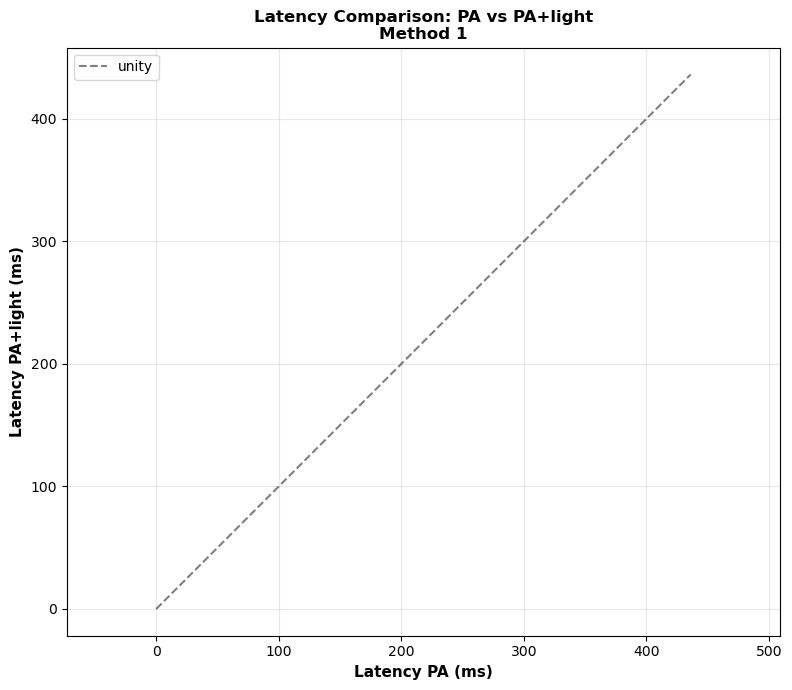


ANALYSIS COMPLETE


In [17]:
# ============================================================
# MAIN ANALYSIS
# ============================================================

print(f"\n{'='*80}")
print(f"PSTH ANALYSIS WITH STATISTICAL TESTING")
print(f"{'='*80}")
print(f"\nPARAMETERS:")
print(f"  Smoothing: ADAPTIVE based on baseline firing rate")
print(f"  Min duration: Excit = {MIN_DURATION_EXCIT_MS} ms, Inhib = {MIN_DURATION_INHIB_MS} ms")
print(f"  Min latency: {MIN_LATENCY_MS} ms")
print(f"  Min baseline for inhibition: {MIN_MU} Hz")

print(f"\nSTATISTICAL TESTING:")
if ENABLE_STATISTICAL_TESTS:
    print(f"  ENABLED")
    print(f"  Significance threshold: α = {SIGNIFICANCE_ALPHA}")
    print(f"  Bonferroni correction: {BONFERRONI_CORRECTION}")
    print(f"  Active tests:")
    for test_name, enabled in STATISTICAL_TESTS.items():
        if enabled:
            if test_name == 'bootstrap':
                print(f"    - Bootstrap ({N_BOOTSTRAP} iterations)")
            elif test_name == 't_test':
                print(f"    - Welch's t-test")
            elif test_name == 'permutation':
                print(f"    - Permutation test ({N_PERMUTATIONS} iterations)")
            elif test_name == 'sliding_window':
                print(f"    - Sliding window (window={WINDOW_SIZE_MS}ms, step={WINDOW_STEP_MS}ms)")
else:
    print(f"  DISABLED (threshold-based detection only)")

print(f"\nMETHODS:")
print(f"  1. SD-based (K_SD_inhib={K_SD_INHIB}, K_SD_excit={K_SD_EXCIT})")
print(f"  2. Percentage-based ({INHIB_PERCENT_DROP}% drop)")
print(f"  4. Percentile-based ({INHIB_PERCENTILE}th percentile)")
print(f"  Primary method: {PRIMARY_METHOD}")
print(f"{'='*80}\n")


# ============================================================
# DATA LOADING
# ============================================================
# NOTE: These variables must be defined before running this script:
# - data_io: Your data I/O object containing cluster_df, burst_df, spiketimes
# - pref_ec_dict: Dictionary mapping cluster_id to preferred electrode
# - selected_rec_names: List of recording names to analyze

print("\nLoading data...")
print("Expected variables:")
print("  - data_io: Object with cluster_df, burst_df, spiketimes")
print("  - pref_ec_dict: {cluster_id: electrode}")
print("  - selected_rec_names: List of recording names")
print("\nIf these are not defined, please define them before running this section.\n")


# ============================================================
# MAIN ANALYSIS LOOP
# ============================================================

cluster_ids = data_io.cluster_df.index.values
output_data = {}
cluster_baseline_rate = {}
method_comparison_data = []
all_results = []

for cluster_id in cluster_ids:
    
    print(f"Processing cluster {cluster_id}")
    
    ec = pref_ec_dict.get(cluster_id)
    if ec is None:
        continue
    
    output_data[cluster_id] = {}
    
    for rec_name in selected_rec_names:
        
        d_select = data_io.burst_df.query(
            'electrode == @ec and recording_name == @rec_name'
        ).copy()
        
        if d_select.empty:
            continue
        
        # Determine stim
        if '_light_pa_' in rec_name:
            stim = "PA+light"
            dcs = d_select.laser_duty_cycle.unique()
        elif '_pa_' in rec_name:
            stim = "PA"
            dcs = d_select.duty_cycle.unique()
        else:
            continue
        
        for dc in sorted(dcs):
            
            # Get train info
            if stim == "PA+light":
                tid = d_select.query('laser_duty_cycle == @dc').iloc[0].train_id
                bd = data_io.burst_df.query('train_id == @tid').iloc[0].laser_burst_duration
            else:
                tid = d_select.query('duty_cycle == @dc').iloc[0].train_id
                bd = data_io.burst_df.query('train_id == @tid').iloc[0].burst_duration
            
            rec_id = str(data_io.burst_df.query('train_id == @tid').iloc[0].rec_id)
            stimtype = str(data_io.burst_df.query('train_id == @tid').iloc[0].stimtype)
            
            # Get burst onsets
            if stimtype in ('laser', 'padmd'):
                burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values
            elif stimtype == 'dmd':
                burst_onsets = data_io.burst_df.query('train_id == @tid').dmd_burst_onset.values
            else:
                continue
            
            # Get spike train for this cluster
            spiketrain = data_io.spiketimes[rec_id][cluster_id]
            
            # Extract spike times relative to stimulus onset
            spike_times = []
            binned = []
            
            for onset in burst_onsets:
                idx = np.where(
                    (spiketrain >= onset + t_edges[0]) &
                    (spiketrain < onset + t_edges[-1])
                )[0]
                
                rel = spiketrain[idx] - onset
                spike_times.append(rel)
                
                counts, _ = np.histogram(rel, bins=t_edges)
                binned.append(counts)
            
            if len(spike_times) == 0:
                continue
            
            binned = np.vstack(binned)
            
            # Calculate firing rate
            spike_counts_per_bin = binned.sum(axis=0)  # Total spikes per bin across trials
            rate = spike_counts_per_bin / (len(spike_times) * (BIN_SIZE_MS/1000))
            
            # Calculate baseline for adaptive smoothing
            baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
            baseline_rate_raw = rate[baseline_mask].mean()
            
            # Baseline filter
            if baseline_rate_raw < MIN_BASELINE_HZ:
                continue
            
            # ADAPTIVE SMOOTHING
            adaptive_smooth_sd = get_adaptive_smooth_sd(baseline_rate_raw)
            rate_smooth = gaussian_filter1d(rate, adaptive_smooth_sd)
            
            # Recalculate baseline statistics on smoothed data
            mu = rate_smooth[baseline_mask].mean()
            sd = rate_smooth[baseline_mask].std(ddof=1)
            
            # Calculate z-score
            if sd > 0:
                zscore = (rate_smooth - mu) / sd
            else:
                zscore = np.zeros_like(rate_smooth)
            
            # Normalize z-score to [-1, 1] range using tanh
            # This maps ±3 SD to ~±0.995, providing smooth saturation
            zscore_normalized = np.tanh(zscore / 3)
            
            cluster_baseline_rate[cluster_id] = mu
            
            # OPTIONAL: Plot z-score before response classification
            # Set PLOT_ZSCORE_DEBUG = True at top of script to enable
            if False:  # Change to True to enable z-score debugging plots
                fig_zscore, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
                
                # Top panel: Raw firing rate
                ax1.plot(t_centers, rate_smooth, 'k-', linewidth=2, label='Firing rate')
                ax1.axhline(mu, color='gray', linestyle='--', alpha=0.6, label=f'Baseline ({mu:.1f} Hz)')
                ax1.axhline(mu + K_SD_EXCIT * sd, color='red', linestyle=':', alpha=0.6, label=f'+{K_SD_EXCIT}σ')
                ax1.axhline(mu - K_SD_INHIB * sd, color='blue', linestyle=':', alpha=0.6, label=f'-{K_SD_INHIB}σ')
                ax1.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5, label='Stimulus')
                ax1.axvline(MIN_LATENCY_MS, color='gray', linestyle=':', linewidth=1, alpha=0.4, label='Detection start')
                ax1.set_ylabel('Firing Rate (Hz)', fontsize=11, fontweight='bold')
                ax1.set_title(f'Cluster {cluster_id} | {stim} | DC={dc} | Train {tid}', 
                             fontsize=12, fontweight='bold')
                ax1.legend(fontsize=8, loc='upper right')
                ax1.grid(alpha=0.3)
                
                # Bottom panel: Normalized z-score
                ax2.plot(t_centers, zscore_normalized, 'k-', linewidth=2, label='Normalized Z-score')
                ax2.axhline(0, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
                ax2.axhline(0.48, color='red', linestyle=':', alpha=0.5, label='~+2σ (z≈0.48)')
                ax2.axhline(-0.48, color='blue', linestyle=':', alpha=0.5, label='~-2σ (z≈-0.48)')
                ax2.axhline(0.76, color='red', linestyle=':', alpha=0.3, label='~+3σ (z≈0.76)')
                ax2.axhline(-0.76, color='blue', linestyle=':', alpha=0.3, label='~-3σ (z≈-0.76)')
                ax2.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5)
                ax2.axvline(MIN_LATENCY_MS, color='gray', linestyle=':', linewidth=1, alpha=0.4)
                ax2.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
                ax2.set_ylabel('Normalized Z-score [-1, 1]', fontsize=11, fontweight='bold')
                ax2.set_ylim([-1.05, 1.05])
                ax2.legend(fontsize=8, loc='upper right')
                ax2.grid(alpha=0.3)
                
                plt.tight_layout()
                plt.show()
            
            # Detect latency with all methods and statistical testing
            all_method_results = detect_latency_all_methods(rate_smooth, mu, sd, spike_counts_per_bin)
            
            # Use primary method for main analysis
            primary_result = all_method_results[PRIMARY_METHOD]
            resp_type = primary_result['resp_type']
            latency_ms = primary_result['latency_ms']
            
            # Skip if no significant response
            if not primary_result['significant']:
                continue
            
            # Calculate response rate
            response_window = (t_centers >= 0) & (t_centers <= 100)
            response_rate = rate_smooth[response_window].mean()
            
            # Store in output_data
            output_data[cluster_id][tid] = dict(
                dc=dc,
                stim=stim,
                response_type=resp_type,
                latency_ms=latency_ms,
                response_rate=response_rate,
                baseline_rate=mu,
                baseline_sd=sd,
                smooth_sd=adaptive_smooth_sd,
                p_value=primary_result['p_value'],
                test_results=primary_result['test_results']
            )
            
            # Store for DataFrame
            all_results.append({
                'cluster_id': cluster_id,
                'train_id': tid,
                'uid': f"{cluster_id}_{tid}",
                'dc': dc,
                'stim': stim,
                'response_type': resp_type,
                'latency_ms': latency_ms,
                'response_rate': response_rate,
                'baseline_rate': mu,
                'p_value': primary_result['p_value'],
                **{f'p_{k}': v for k, v in primary_result['test_results'].items() if k != 'sliding_window_latency'}
            })
            
            # Store method comparison data
            for method_id in [1, 2, 4]:
                mres = all_method_results[method_id]
                if mres['significant']:
                    method_comparison_data.append({
                        'cluster_id': cluster_id,
                        'train_id': tid,
                        'dc': dc,
                        'stim': stim,
                        'method': method_id,
                        'method_name': mres['method_name'],
                        'resp_type': mres['resp_type'],
                        'latency_ms': mres['latency_ms'],
                        'p_value': mres['p_value']
                    })

# ============================================================
# CREATE DATAFRAMES
# ============================================================

df = pd.DataFrame(all_results)
method_df = pd.DataFrame(method_comparison_data)

df.to_csv(f'{figure_dir}/{session_id}_psth_df.csv')

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"\nTotal responses detected (primary method {PRIMARY_METHOD}): {len(df)}")
if len(df) > 0:
    print(f"  Excitatory: {len(df[df.response_type == 'excitatory'])} ({100*len(df[df.response_type == 'excitatory'])/len(df):.1f}%)")
    print(f"  Inhibitory: {len(df[df.response_type == 'inhibitory'])} ({100*len(df[df.response_type == 'inhibitory'])/len(df):.1f}%)")
    
    if ENABLE_STATISTICAL_TESTS:
        print(f"\nP-value statistics:")
        print(f"  Mean p-value: {df.p_value.mean():.4f}")
        print(f"  Median p-value: {df.p_value.median():.4f}")
        print(f"  Min p-value: {df.p_value.min():.4f}")
        print(f"  Max p-value: {df.p_value.max():.4f}")
        
        # Significance levels
        p001 = len(df[df.p_value < 0.001])
        p01 = len(df[(df.p_value >= 0.001) & (df.p_value < 0.01)])
        p05 = len(df[(df.p_value >= 0.01) & (df.p_value < 0.05)])
        
        print(f"\nSignificance levels:")
        print(f"  p < 0.001 (***): {p001} ({100*p001/len(df):.1f}%)")
        print(f"  0.001 ≤ p < 0.01 (**): {p01} ({100*p01/len(df):.1f}%)")
        print(f"  0.01 ≤ p < 0.05 (*): {p05} ({100*p05/len(df):.1f}%)")
        
        # Individual test statistics
        test_cols = [col for col in df.columns if col.startswith('p_')]
        if test_cols:
            print(f"\nIndividual test p-values (mean):")
            for col in test_cols:
                test_name = col.replace('p_', '').replace('_', ' ').title()
                print(f"  {test_name}: {df[col].mean():.4f}")
    
    print(f"\nBy stim:")
    for stim in df.stim.unique():
        cond_df = df[df.stim == stim]
        print(f"  {stim}: {len(cond_df)} responses")
        exc = len(cond_df[cond_df.response_type == 'excitatory'])
        inh = len(cond_df[cond_df.response_type == 'inhibitory'])
        print(f"    Excitatory: {exc}, Inhibitory: {inh}")
else:
    print("  No significant responses detected!")
    print("\nTroubleshooting tips:")
    print("  - Try setting ENABLE_STATISTICAL_TESTS = False to see threshold crossings")
    print("  - Increase SIGNIFICANCE_ALPHA (e.g., 0.10)")
    print("  - Disable BONFERRONI_CORRECTION")
    print("  - Check your data loading is working correctly")

print("="*80)

# ============================================================
# SUMMARY PLOTS
# ============================================================

if len(df) > 0:
    print("\n" + "="*80)
    print("GENERATING SUMMARY PLOTS")
    print("="*80)
    
    # ============================================================
    # SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light
    # ============================================================
    
    plt.figure(figsize=(8, 7))
    
    for dc in sorted(df.dc.unique()):
        
        sub = df[df.dc == dc]
        
        pa = sub[sub.stim == "PA"]
        pl = sub[sub.stim == "PA+light"]
        
        merged = pd.merge(pa, pl, on=["uid", "dc"], suffixes=("_pa", "_pl"))
        merged.to_csv(f'{figure_dir}/{session_id}_merged_df.csv')
        
        if merged.empty:
            continue
        
        for _, r in merged.iterrows():
            
            shade = int(dc) % 10
            color = get_color("PA", r.response_type_pa, shade)
            
            plt.scatter(r.latency_ms_pa, r.latency_ms_pl, color=color, s=50, alpha=0.7)
    
    # Unity line
    if len(df) > 0:
        max_lat = df.latency_ms.max()
        plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')
    
    plt.xlabel("Latency PA (ms)", fontsize=11, fontweight='bold')
    plt.ylabel("Latency PA+light (ms)", fontsize=11, fontweight='bold')
    plt.title(f"Latency Comparison: PA vs PA+light\nMethod {PRIMARY_METHOD}", 
             fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    # plt.savefig(f'{figure_dir}/test/summary_latency_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: summary_latency_comparison.png")
    plt.show()
    
#     # ============================================================
#     # SUMMARY PLOT 2: EXCITATORY RESPONSE RATE
#     # ============================================================
    
#     plt.figure(figsize=(8, 7))
    
#     df_exc = df[df.response_type == "excitatory"]
    
#     if not df_exc.empty:
#         for dc in sorted(df_exc.dc.unique()):
            
#             sub = df_exc[df_exc.dc == dc]
            
#             pa = sub[sub.stim == "PA"]
#             pl = sub[sub.stim == "PA+light"]
            
#             merged = pd.merge(pa, pl, on=["uid", "dc"], suffixes=("_pa", "_pl"))
            
#             if merged.empty:
#                 continue
            
#             shade = int(dc) % 10
#             color = get_color("PA+light", "excitatory", shade)
            
#             plt.scatter(
#                 merged.response_rate_pa,
#                 merged.response_rate_pl,
#                 color=color,
#                 s=50,
#                 alpha=0.7,
#                 label=f"dc={dc}"
#             )
        
#         # Unity line
#         maxv = df_exc.response_rate.max()
#         plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='unity')
        
#         plt.xlabel("Response rate PA (Hz)", fontsize=11, fontweight='bold')
#         plt.ylabel("Response rate PA+light (Hz)", fontsize=11, fontweight='bold')
#         plt.title(f"Excitatory Response Rate: PA vs PA+light\nMethod {PRIMARY_METHOD}", 
#                  fontsize=12, fontweight='bold')
#         plt.legend(fontsize=9)
#         plt.grid(alpha=0.3)
#         plt.axis('equal')
#         plt.tight_layout()
#         plt.savefig(f'{figure_dir}/test/summary_excitatory_response_rate.png', dpi=150, bbox_inches='tight')
#         print("✓ Saved: summary_excitatory_response_rate.png")
#         plt.show()
#     else:
#         print("No excitatory responses found for comparison plot.")
    
#     # ============================================================
#     # SUMMARY PLOT 3: INHIBITORY RESPONSE RATE
#     # ============================================================
    
#     plt.figure(figsize=(8, 7))
    
#     df_inh = df[df.response_type == "inhibitory"]
    
#     if not df_inh.empty:
#         for dc in sorted(df_inh.dc.unique()):
            
#             sub = df_inh[df_inh.dc == dc]
            
#             pa = sub[sub.stim == "PA"]
#             pl = sub[sub.stim == "PA+light"]
            
#             merged = pd.merge(pa, pl, on=["uid", "dc"], suffixes=("_pa", "_pl"))
            
#             if merged.empty:
#                 continue
            
#             shade = int(dc) % 10
#             color = get_color("PA+light", "inhibitory", shade)
            
#             plt.scatter(
#                 merged.response_rate_pa,
#                 merged.response_rate_pl,
#                 color=color,
#                 s=50,
#                 alpha=0.7,
#                 label=f"dc={dc}"
#             )
        
#         # Unity line
#         maxv = df_inh.response_rate.max()
#         plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='unity')
        
#         plt.xlabel("Response rate PA (Hz)", fontsize=11, fontweight='bold')
#         plt.ylabel("Response rate PA+light (Hz)", fontsize=11, fontweight='bold')
#         plt.title(f"Inhibitory Response Rate: PA vs PA+light\nMethod {PRIMARY_METHOD}", 
#                  fontsize=12, fontweight='bold')
#         plt.legend(fontsize=9)
#         plt.grid(alpha=0.3)
#         plt.axis('equal')
#         plt.tight_layout()
#         plt.savefig(f'{figure_dir}/test/summary_inhibitory_response_rate.png', dpi=150, bbox_inches='tight')
#         print("✓ Saved: summary_inhibitory_response_rate.png")
#         plt.show()
#     else:
#         print("No inhibitory responses found for comparison plot.")
    
#     print("\n" + "="*80)
#     print("SUMMARY PLOTS COMPLETE")
#     print("="*80)

# # ============================================================
# # Z-SCORE CALCULATION AND HEATMAP VISUALIZATION
# # ============================================================

# if len(df) > 0:
#     print("\n" + "="*80)
#     print("GENERATING Z-SCORE HEATMAPS")
#     print("="*80)
    
#     # Collect z-scored PSTHs for each cluster/stim/dc
#     zscore_data = {}
    
#     for cluster_id in cluster_ids:
        
#         ec = pref_ec_dict.get(cluster_id)
#         if ec is None:
#             continue
        
#         for rec_name in selected_rec_names:
            
#             d_select = data_io.burst_df.query(
#                 'electrode == @ec and recording_name == @rec_name'
#             ).copy()
            
#             if d_select.empty:
#                 continue
            
#             # Determine stim
#             if '_light_pa_' in rec_name:
#                 stim = "PA+light"
#                 dcs = d_select.laser_duty_cycle.unique()
#             elif '_pa_' in rec_name:
#                 stim = "PA"
#                 dcs = d_select.duty_cycle.unique()
#             else:
#                 continue
            
#             for dc in sorted(dcs):
                
#                 # Get train info
#                 if stim == "PA+light":
#                     tid = d_select.query('laser_duty_cycle == @dc').iloc[0].train_id
#                 else:
#                     tid = d_select.query('duty_cycle == @dc').iloc[0].train_id
                
#                 # Check if this response was significant
#                 response_key = (cluster_id, tid)
#                 if response_key not in [(r['cluster_id'], r['train_id']) for r in all_results]:
#                     continue
                
#                 rec_id = str(data_io.burst_df.query('train_id == @tid').iloc[0].rec_id)
#                 stimtype = str(data_io.burst_df.query('train_id == @tid').iloc[0].stimtype)
                
#                 # Get burst onsets
#                 if stimtype in ('laser', 'padmd'):
#                     burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values
#                 elif stimtype == 'dmd':
#                     burst_onsets = data_io.burst_df.query('train_id == @tid').dmd_burst_onset.values
#                 else:
#                     continue
                
#                 # Get spike train
#                 spiketrain = data_io.spiketimes[rec_id][cluster_id]
                
#                 # Extract spike times
#                 binned = []
#                 for onset in burst_onsets:
#                     idx = np.where(
#                         (spiketrain >= onset + t_edges[0]) &
#                         (spiketrain < onset + t_edges[-1])
#                     )[0]
#                     rel = spiketrain[idx] - onset
#                     counts, _ = np.histogram(rel, bins=t_edges)
#                     binned.append(counts)
                
#                 if len(binned) == 0:
#                     continue
                
#                 binned = np.vstack(binned)
                
#                 # Calculate firing rate
#                 rate = binned.sum(axis=0) / (len(binned) * (BIN_SIZE_MS/1000))
                
#                 # Calculate baseline
#                 baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
#                 baseline_rate = rate[baseline_mask].mean()
                
#                 if baseline_rate < MIN_BASELINE_HZ:
#                     continue
                
#                 # Adaptive smoothing
#                 adaptive_smooth_sd = get_adaptive_smooth_sd(baseline_rate)
#                 rate_smooth = gaussian_filter1d(rate, adaptive_smooth_sd)
                
#                 # Calculate z-score
#                 mu = rate_smooth[baseline_mask].mean()
#                 sd = rate_smooth[baseline_mask].std(ddof=1)
                
#                 if sd > 0:
#                     zscore = (rate_smooth - mu) / sd
#                 else:
#                     zscore = np.zeros_like(rate_smooth)
                
#                 # Normalize z-score to [-1, 1] using tanh
#                 zscore_normalized = np.tanh(zscore / 3)
                
#                 # Store z-scored PSTH
#                 key = (cluster_id, stim, dc)
#                 zscore_data[key] = {
#                     'zscore': zscore_normalized,  # Use normalized z-score
#                     'zscore_raw': zscore,         # Keep raw z-score for reference
#                     'rate': rate_smooth,
#                     'cluster_id': cluster_id,
#                     'stim': stim,
#                     'dc': dc,
#                     'train_id': tid
#                 }
    
#     print(f"Collected {len(zscore_data)} z-scored PSTHs")
    
    # ============================================================
    # HEATMAP 1: PA stim by duty cycle
    # ============================================================
    
    # # Get response types from results for sorting
    # response_type_map = {(r['cluster_id'], r['train_id']): r['response_type'] for r in all_results}
    # latency_map = {(r['cluster_id'], r['train_id']): r['latency_ms'] for r in all_results}
    
    # # Add response type and latency to zscore_data
    # for key, data in zscore_data.items():
    #     lookup_key = (data['cluster_id'], data['train_id'])
    #     data['response_type'] = response_type_map.get(lookup_key, 'unknown')
    #     data['latency'] = latency_map.get(lookup_key, np.nan)
    
    # pa_data = {k: v for k, v in zscore_data.items() if v['stim'] == 'PA'}
    
    # if len(pa_data) > 0:
    #     pa_dcs = sorted(list(set([v['dc'] for v in pa_data.values()])))
        
    #     fig, axes = plt.subplots(len(pa_dcs), 1, figsize=(14, 3*len(pa_dcs)))
    #     if len(pa_dcs) == 1:
    #         axes = [axes]
        
    #     for idx, dc in enumerate(pa_dcs):
    #         ax = axes[idx]
            
    #         dc_responses = [(k, v) for k, v in pa_data.items() if v['dc'] == dc]
            
    #         if len(dc_responses) == 0:
    #             ax.text(0.5, 0.5, f'No data for DC={dc}', 
    #                    ha='center', va='center', transform=ax.transAxes)
    #             ax.set_title(f'PA | DC={dc}', fontweight='bold')
    #             continue
            
    #         # SORTING STRATEGY:
    #         # 1. First by response type: excitatory (0) then inhibitory (1)
    #         # 2. Within each type, sort by latency DESCENDING (slowest first, fastest last)
    #         # This puts:
    #         #   - Excitatory responses at top: slowest at top, fastest at bottom
    #         #   - Inhibitory responses at bottom: slowest at top, fastest at bottom

            
    #         dc_responses = sorted(dc_responses, key=sort_key)
            
    #         n_units = len(dc_responses)
    #         zscore_matrix = np.zeros((n_units, len(t_centers)))
            
    #         cluster_labels = []
    #         for i, (key, data) in enumerate(dc_responses):
    #             zscore_matrix[i, :] = data['zscore']
    #             resp_type = data.get('response_type', '?')
    #             latency = data.get('latency', np.nan)
    #             resp_abbrev = 'E' if resp_type == 'excitatory' else 'I' if resp_type == 'inhibitory' else '?'
    #             cluster_labels.append(f"C{data['cluster_id']} ({resp_abbrev}, {latency:.1f}ms)")
            
    #         im = ax.imshow(zscore_matrix, aspect='auto', cmap='RdBu_r', 
    #                       vmin=-1, vmax=1, interpolation='nearest',
    #                       extent=[t_centers[0], t_centers[-1], n_units-0.5, -0.5])
            
    #         ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.8)
    #         ax.axvline(MIN_LATENCY_MS, color='gray', linewidth=1, linestyle=':', alpha=0.5)
            
    #         ax.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
    #         ax.set_ylabel('Unit', fontsize=11, fontweight='bold')
    #         ax.set_title(f'PA | Duty Cycle = {dc}% | n={n_units} units', 
    #                     fontsize=12, fontweight='bold')
            
    #         ax.set_yticks(range(n_units))
    #         # ax.set_yticklabels(cluster_labels, fontsize=8)
            
    #         cbar = plt.colorbar(im, ax=ax)
    #         cbar.set_label('Normalized Z-score', fontsize=10, fontweight='bold')
        
    #     plt.suptitle('PA stim - Normalized Z-scored PSTHs by Duty ' \
    #                 'Cycle', fontsize=14, fontweight='bold')
    #     plt.tight_layout()
    #     plt.savefig(f'{figure_dir}/test/{session_id}_heatmap_PA.png', dpi=150, bbox_inches='tight')
    #     print("✓ Saved: heatmap_PA.png")
    #     plt.show()
    
    # # ============================================================
    # # HEATMAP 2: PA+light stim by duty cycle
    # # ============================================================
    
    # palight_data = {k: v for k, v in zscore_data.items() if v['stim'] == 'PA+light'}
    
    # if len(palight_data) > 0:
    #     palight_dcs = sorted(list(set([v['dc'] for v in palight_data.values()])))
        
    #     fig, axes = plt.subplots(len(palight_dcs), 1, figsize=(14, 3*len(palight_dcs)))
    #     if len(palight_dcs) == 1:
    #         axes = [axes]
        
    #     for idx, dc in enumerate(palight_dcs):
    #         ax = axes[idx]
            
    #         dc_responses = [(k, v) for k, v in palight_data.items() if v['dc'] == dc]
            
    #         if len(dc_responses) == 0:
    #             ax.text(0.5, 0.5, f'No data for DC={dc}', 
    #                    ha='center', va='center', transform=ax.transAxes)
    #             ax.set_title(f'PA+light | DC={dc}', fontweight='bold')
    #             continue
            
    #         # Same sorting: excitatory first (top), then inhibitory (bottom), both slowest→fastest
    #         def sort_key(item):
    #             data = item[1]
    #             resp_type = data.get('response_type', 'unknown')
    #             latency = data.get('latency', 999)
    #             type_order = 0 if resp_type == 'excitatory' else 1
    #             return (type_order, -latency)  # Negate latency for descending order
            
    #         dc_responses = sorted(dc_responses, key=sort_key)
            
    #         n_units = len(dc_responses)
    #         zscore_matrix = np.zeros((n_units, len(t_centers)))
            
    #         cluster_labels = []
    #         for i, (key, data) in enumerate(dc_responses):
    #             zscore_matrix[i, :] = data['zscore']
    #             resp_type = data.get('response_type', '?')
    #             latency = data.get('latency', np.nan)
    #             resp_abbrev = 'E' if resp_type == 'excitatory' else 'I' if resp_type == 'inhibitory' else '?'
    #             cluster_labels.append(f"C{data['cluster_id']} ({resp_abbrev}, {latency:.1f}ms)")
            
    #         im = ax.imshow(zscore_matrix, aspect='auto', cmap='RdBu_r', 
    #                       vmin=-1, vmax=1, interpolation='nearest',
    #                       extent=[t_centers[0], t_centers[-1], n_units-0.5, -0.5])
            
    #         ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.8)
    #         ax.axvline(MIN_LATENCY_MS, color='gray', linewidth=1, linestyle=':', alpha=0.5)
            
    #         ax.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
    #         ax.set_ylabel('Unit', fontsize=11, fontweight='bold')
    #         ax.set_title(f'PA+light | Duty Cycle = {dc}% | n={n_units} units', 
    #                     fontsize=12, fontweight='bold')
            
    #         # ax.set_yticks(range(n_units))
    #         # ax.set_yticklabels(cluster_labels, fontsize=8)
            
    #         cbar = plt.colorbar(im, ax=ax)
    #         cbar.set_label('Normalized Z-score', fontsize=10, fontweight='bold')
        
    #     plt.suptitle('PA+light stim - Normalized Z-scored PSTHs by Duty Cycle', 
    #                 fontsize=14, fontweight='bold')
    #     plt.tight_layout()
    #     plt.savefig(f'{figure_dir}/test/{session_id}_heatmap_PA_light.png', dpi=150, bbox_inches='tight')
    #     print("✓ Saved: heatmap_PA_light.png")
    #     plt.show()
    
    # ============================================================
    # HEATMAP 3: Combined view - PA vs PA+light for each DC
    # ============================================================
    
    # all_dcs = sorted(list(set([v['dc'] for v in zscore_data.values()])))
    
    # if len(all_dcs) > 0:
    #     fig, axes = plt.subplots(len(all_dcs), 2, figsize=(16, 3*len(all_dcs)))
    #     if len(all_dcs) == 1:
    #         axes = axes.reshape(1, -1)
        
    #     for idx, dc in enumerate(all_dcs):
            
    #         for col_idx, stim in enumerate(['PA', 'PA+light']):
    #             ax = axes[idx, col_idx]
                
    #             dc_cond_responses = [(k, v) for k, v in zscore_data.items() 
    #                                 if v['dc'] == dc and v['stim'] == stim]
                
    #             if len(dc_cond_responses) == 0:
    #                 ax.text(0.5, 0.5, f'No data\nDC={dc}\n{stim}', 
    #                        ha='center', va='center', transform=ax.transAxes, fontsize=10)
    #                 ax.set_title(f'{stim} | DC={dc}%', fontweight='bold')
    #                 continue
                
    #             dc_cond_responses = sorted(dc_cond_responses, key=sort_key)

    #             # Same sorting: excitatory first, then inhibitory, both slowest→fastest
    #             # def sort_key(item):
    #             #     data = item[1]
    #             #     resp_type = data.get('response_type', 'unknown')
    #             #     latency = data.get('latency', 999)
    #             #     type_order = 0 if resp_type == 'excitatory' else 1
    #             #     return (type_order, -latency)  # Negate latency for descending order
                
    #             n_units = len(dc_cond_responses)
    #             zscore_matrix = np.zeros((n_units, len(t_centers)))
                
    #             cluster_labels = []
    #             for i, (key, data) in enumerate(dc_cond_responses):
    #                 zscore_matrix[i, :] = data['zscore']
    #                 resp_type = data.get('response_type', '?')
    #                 latency = data.get('latency', np.nan)
    #                 resp_abbrev = 'E' if resp_type == 'excitatory' else 'I' if resp_type == 'inhibitory' else '?'
    #                 cluster_labels.append(f"C{data['cluster_id']} ({resp_abbrev}, {latency:.1f}ms)")
                
    #             im = ax.imshow(zscore_matrix, aspect='auto', cmap='RdBu_r', 
    #                           vmin=-1, vmax=1, interpolation='nearest',
    #                           extent=[t_centers[0], t_centers[-1], n_units-0.5, -0.5])
                
    #             ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.8)
    #             ax.axvline(MIN_LATENCY_MS, color='gray', linewidth=1, linestyle=':', alpha=0.5)
                
    #             for i, (key, data) in enumerate(dc_cond_responses):
    #                 lat = data.get('latency', np.nan)
    #                 if not np.isnan(lat):
    #                     ax.plot(lat, i, 'k*', markersize=8, markeredgecolor='white', markeredgewidth=0.5)

    #             if idx == len(all_dcs) - 1:
    #                 ax.set_xlabel('Time (ms)', fontsize=10, fontweight='bold')
    #             if col_idx == 0:
    #                 ax.set_ylabel('Unit', fontsize=10, fontweight='bold')
                
    #             ax.set_title(f'{stim} | DC={dc}% | n={n_units}', 
    #                         fontsize=11, fontweight='bold')
                
    #             # ax.set_yticks(range(n_units))
    #             # ax.set_yticklabels(cluster_labels, fontsize=7)
                
    #             if col_idx == 1:
    #                 cbar = plt.colorbar(im, ax=ax)
    #                 cbar.set_label('Normalized Z-score', fontsize=9)
        
    #     plt.suptitle('Normalized Z-scored PSTHs: PA vs PA+light by Duty Cycle', 
    #                 fontsize=14, fontweight='bold')
    #     plt.tight_layout()
    #     plt.savefig(f'{figure_dir}/test/{session_id}_heatmap_combined.png', dpi=150, bbox_inches='tight')
    #     print("✓ Saved: heatmap_combined.png")
    #     plt.show()
    
    # # ============================================================
    # # HEATMAP 4: Sorted by response latency
    # # ============================================================

    # for stim in ['PA', 'PA+light']:
    #     cond_data = {k: v for k, v in zscore_data.items() if v['stim'] == stim}
        
    #     if len(cond_data) == 0:
    #         continue
        
    #     latency_map = {(r['cluster_id'], r['train_id']): r['latency_ms'] for r in all_results}
        
    #     for key, data in cond_data.items():
    #         lookup_key = (data['cluster_id'], data['train_id'])
    #         data['latency'] = latency_map.get(lookup_key, np.nan)
        
    #     dcs = sorted(list(set([v['dc'] for v in cond_data.values()])))
        
    #     fig, axes = plt.subplots(len(dcs), 1, figsize=(14, 3*len(dcs)))
    #     if len(dcs) == 1:
    #         axes = [axes]
        
    #     for idx, dc in enumerate(dcs):
    #         ax = axes[idx]
            
    #         dc_responses = [(k, v) for k, v in cond_data.items() if v['dc'] == dc]
            
    #         if len(dc_responses) == 0:
    #             continue
            
    #         # Sort by response type first, then by latency (descending - slowest first)
    #         # def sort_key(item):
    #         #     data = item[1]
    #         #     resp_type = data.get('response_type', 'unknown')
    #         #     latency = data.get('latency', 999)
    #         #     # excitatory=0 (top), inhibitory=1 (bottom)
    #         #     type_order = 0 if resp_type == 'excitatory' else 1
    #         #     return (type_order, -latency)  # Negate for slowest→fastest
            
    #         dc_responses = sorted(dc_responses, key=sort_key)
            
    #         n_units = len(dc_responses)
    #         zscore_matrix = np.zeros((n_units, len(t_centers)))
            
    #         cluster_labels = []
    #         for i, (key, data) in enumerate(dc_responses):
    #             zscore_matrix[i, :] = data['zscore']
    #             lat = data.get('latency', np.nan)
    #             resp_type = data.get('response_type', '?')
    #             resp_abbrev = 'E' if resp_type == 'excitatory' else 'I' if resp_type == 'inhibitory' else '?'
    #             cluster_labels.append(f"C{data['cluster_id']} ({resp_abbrev}, {lat:.1f}ms)")
            
    #         im = ax.imshow(zscore_matrix, aspect='auto', cmap='RdBu_r', 
    #                       vmin=-1, vmax=1, interpolation='nearest',
    #                       extent=[t_centers[0], t_centers[-1], n_units-0.5, -0.5])
            
    #         ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.8, label='Stimulus')
    #         ax.axvline(MIN_LATENCY_MS, color='gray', linewidth=1, linestyle=':', alpha=0.5)
            
    #         for i, (key, data) in enumerate(dc_responses):
    #             lat = data.get('latency', np.nan)
    #             if not np.isnan(lat):
    #                 ax.plot(lat, i, 'k*', markersize=8, markeredgecolor='white', markeredgewidth=0.5)
            
    #         ax.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
    #         ax.set_ylabel('Unit', fontsize=11, fontweight='bold')
    #         ax.set_title(f'{stim} | DC={dc}% | n={n_units}', 
    #                     fontsize=12, fontweight='bold')
            
    #         # ax.set_yticks(range(n_units))
    #         # ax.set_yticklabels(cluster_labels, fontsize=7)
            
    #         cbar = plt.colorbar(im, ax=ax)
    #         cbar.set_label('Normalized Z-score', fontsize=10, fontweight='bold')
        
    #     plt.suptitle(f'{stim} - Sorted by Response Type then Latency', 
    #                 fontsize=14, fontweight='bold')
    #     plt.tight_layout()
    #     filename = f'{figure_dir}/test/{session_id}_heatmap_{stim.replace("+", "_")}_sorted.png'
#         plt.savefig(filename, dpi=150, bbox_inches='tight')
#         print(f"✓ Saved: heatmap_{stim.replace('+', '_')}_sorted.png")
#         plt.show()
    
#     print("\n" + "="*80)
#     print("Z-SCORE HEATMAPS COMPLETE")
#     print("="*80)

# else:
#     print("\nNo significant responses detected - skipping heatmap generation.")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)

In [18]:
# ============================================================
# MAIN ANALYSIS - MODIFY HERE
# ============================================================

print(f"\n{'='*80}")
print(f"PSTH ANALYSIS WITH STATISTICAL TESTING")
print(f"{'='*80}")
print(f"\nPARAMETERS:")
print(f"  Smoothing: ADAPTIVE based on baseline firing rate")
print(f"  Min duration: Excit = {MIN_DURATION_EXCIT_MS} ms, Inhib = {MIN_DURATION_INHIB_MS} ms")
print(f"  Min latency: {MIN_LATENCY_MS} ms")
print(f"  Min baseline for inhibition: {MIN_MU} Hz")

print(f"\nSTATISTICAL TESTING:")
if ENABLE_STATISTICAL_TESTS:
    print(f"  ENABLED")
    print(f"  Significance threshold: α = {SIGNIFICANCE_ALPHA}")
    print(f"  Bonferroni correction: {BONFERRONI_CORRECTION}")
    print(f"  Active tests:")
    for test_name, enabled in STATISTICAL_TESTS.items():
        if enabled:
            if test_name == 'bootstrap':
                print(f"    - Bootstrap ({N_BOOTSTRAP} iterations)")
            elif test_name == 't_test':
                print(f"    - Welch's t-test")
            elif test_name == 'permutation':
                print(f"    - Permutation test ({N_PERMUTATIONS} iterations)")
            elif test_name == 'sliding_window':
                print(f"    - Sliding window (window={WINDOW_SIZE_MS}ms, step={WINDOW_STEP_MS}ms)")
else:
    print(f"  DISABLED (threshold-based detection only)")

print(f"\nMETHODS:")
print(f"  1. SD-based (K_SD_inhib={K_SD_INHIB}, K_SD_excit={K_SD_EXCIT})")
print(f"  2. Percentage-based ({INHIB_PERCENT_DROP}% drop)")
print(f"  4. Percentile-based ({INHIB_PERCENTILE}th percentile)")
print(f"  Primary method: {PRIMARY_METHOD}")
print(f"{'='*80}\n")


# ============================================================
# DATA LOADING
# ============================================================
# NOTE: These variables must be defined before running this script:
# - data_io: Your data I/O object containing cluster_df, burst_df, spiketimes
# - pref_ec_dict: Dictionary mapping cluster_id to preferred electrode
# - selected_rec_names: List of recording names to analyze

print("\nLoading data...")
print("Expected variables:")
print("  - data_io: Object with cluster_df, burst_df, spiketimes")
print("  - pref_ec_dict: {cluster_id: electrode}")
print("  - selected_rec_names: List of recording names")
print("\nIf these are not defined, please define them before running this section.\n")


# ============================================================
# MAIN ANALYSIS LOOP
# ============================================================

cluster_ids = data_io.cluster_df.index.values
output_data = {}
cluster_baseline_rate = {}
method_comparison_data = []
all_results = []

for cluster_id in cluster_ids:
    
    print(f"Processing cluster {cluster_id}")
    
    # Load preferred PA stim electrode
    ec = pref_ec_dict.get(cluster_id)
    if ec is None:
        continue
    
    output_data[cluster_id] = {}
    
    # Loop over all recordings
    for rec_name in selected_rec_names:
        
        d_select = data_io.burst_df.query(
            'electrode == @ec and recording_name == @rec_name'
        ).copy()
        
        if d_select.empty:
            continue
        
        # Determine stim
        if '_light_pa_' in rec_name:
            stim = "PA+light"
            duty_cycles = d_select.laser_duty_cycle.unique()
        elif '_pa_' in rec_name:
            stim = "PA"
            duty_cycles = d_select.duty_cycle.unique()
        else:
            continue
        
        for dc in sorted(duty_cycles):
            
            # Get train info
            if stim == "PA+light":
                tid = d_select.query('laser_duty_cycle == @dc').iloc[0].train_id
                bd = data_io.burst_df.query('train_id == @tid').iloc[0].laser_burst_duration
            else:
                tid = d_select.query('duty_cycle == @dc').iloc[0].train_id
                bd = data_io.burst_df.query('train_id == @tid').iloc[0].burst_duration
            
            rec_id = str(data_io.burst_df.query('train_id == @tid').iloc[0].rec_id)
            stimtype = str(data_io.burst_df.query('train_id == @tid').iloc[0].stimtype)
            
            # Get burst onsets
            if stimtype in ('laser', 'padmd'):
                burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values
            elif stimtype == 'dmd':
                burst_onsets = data_io.burst_df.query('train_id == @tid').dmd_burst_onset.values
            else:
                continue
            
            # Get spike train for this cluster
            spiketrain = data_io.spiketimes[rec_id][cluster_id]
            
            # Extract spike times relative to stimulus onset
            spike_times = []
            binned = []
            
            for onset in burst_onsets:
                idx = np.where(
                    (spiketrain >= onset + t_edges[0]) &
                    (spiketrain < onset + t_edges[-1])
                )[0]
                
                rel = spiketrain[idx] - onset
                spike_times.append(rel)
                
                counts, _ = np.histogram(rel, bins=t_edges)
                binned.append(counts)
            
            if len(spike_times) == 0:
                continue
            
            binned = np.vstack(binned)
            
            # Calculate firing rate
            spike_counts_per_bin = binned.sum(axis=0)  # Total spikes per bin across trials
            rate = spike_counts_per_bin / (len(spike_times) * (BIN_SIZE_MS/1000))
            
            # Calculate baseline for adaptive smoothing
            baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
            baseline_rate_raw = rate[baseline_mask].mean()
            
            # Baseline filter
            if baseline_rate_raw < MIN_BASELINE_HZ:
                continue
            
            # ADAPTIVE SMOOTHING
            adaptive_smooth_sd = get_adaptive_smooth_sd(baseline_rate_raw)
            rate_smooth = gaussian_filter1d(rate, adaptive_smooth_sd)
            
            # Recalculate baseline statistics on smoothed data
            mu = rate_smooth[baseline_mask].mean()
            sd = rate_smooth[baseline_mask].std(ddof=1)
            
            # Calculate z-score
            if sd > 0:
                zscore = (rate_smooth - mu) / sd
            else:
                zscore = np.zeros_like(rate_smooth)
            
            # Normalize z-score to [-1, 1] range using tanh
            # This maps ±3 SD to ~±0.995, providing smooth saturation
            zscore_normalized = np.tanh(zscore / 3)
            
            cluster_baseline_rate[cluster_id] = mu
            
            # OPTIONAL: Plot z-score before response classification
            # Set PLOT_ZSCORE_DEBUG = True at top of script to enable
            if False:  # Change to True to enable z-score debugging plots
                fig_zscore, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
                
                # Top panel: Raw firing rate
                ax1.plot(t_centers, rate_smooth, 'k-', linewidth=2, label='Firing rate')
                ax1.axhline(mu, color='gray', linestyle='--', alpha=0.6, label=f'Baseline ({mu:.1f} Hz)')
                ax1.axhline(mu + K_SD_EXCIT * sd, color='red', linestyle=':', alpha=0.6, label=f'+{K_SD_EXCIT}σ')
                ax1.axhline(mu - K_SD_INHIB * sd, color='blue', linestyle=':', alpha=0.6, label=f'-{K_SD_INHIB}σ')
                ax1.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5, label='Stimulus')
                ax1.axvline(MIN_LATENCY_MS, color='gray', linestyle=':', linewidth=1, alpha=0.4, label='Detection start')
                ax1.set_ylabel('Firing Rate (Hz)', fontsize=11, fontweight='bold')
                ax1.set_title(f'Cluster {cluster_id} | {stim} | DC={dc} | Train {tid}', 
                             fontsize=12, fontweight='bold')
                ax1.legend(fontsize=8, loc='upper right')
                ax1.grid(alpha=0.3)
                
                # Bottom panel: Normalized z-score
                ax2.plot(t_centers, zscore_normalized, 'k-', linewidth=2, label='Normalized Z-score')
                ax2.axhline(0, color='gray', linestyle='--', alpha=0.6, linewidth=1.5)
                ax2.axhline(0.48, color='red', linestyle=':', alpha=0.5, label='~+2σ (z≈0.48)')
                ax2.axhline(-0.48, color='blue', linestyle=':', alpha=0.5, label='~-2σ (z≈-0.48)')
                ax2.axhline(0.76, color='red', linestyle=':', alpha=0.3, label='~+3σ (z≈0.76)')
                ax2.axhline(-0.76, color='blue', linestyle=':', alpha=0.3, label='~-3σ (z≈-0.76)')
                ax2.axvline(0, color='k', linestyle='--', linewidth=1.5, alpha=0.5)
                ax2.axvline(MIN_LATENCY_MS, color='gray', linestyle=':', linewidth=1, alpha=0.4)
                ax2.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
                ax2.set_ylabel('Normalized Z-score [-1, 1]', fontsize=11, fontweight='bold')
                ax2.set_ylim([-1.05, 1.05])
                ax2.legend(fontsize=8, loc='upper right')
                ax2.grid(alpha=0.3)
                
                plt.tight_layout()
                plt.show()
            
            # Detect latency with all methods and statistical testing
            all_method_results = detect_latency_all_methods(rate_smooth, mu, sd, spike_counts_per_bin)
            
            # Use primary method for main analysis
            primary_result = all_method_results[PRIMARY_METHOD]
            resp_type = primary_result['resp_type']
            latency_ms = primary_result['latency_ms']
            
            # Skip if no significant response
            if not primary_result['significant']:
                continue
            
            # Calculate response rate
            response_window = (t_centers >= 0) & (t_centers <= 100)
            response_rate = rate_smooth[response_window].mean()
            
            # Store in output_data
            output_data[cluster_id][tid] = dict(
                dc=dc,
                stim=stim,
                response_type=resp_type,
                latency_ms=latency_ms,
                response_rate=response_rate,
                baseline_rate=mu,
                baseline_sd=sd,
                smooth_sd=adaptive_smooth_sd,
                p_value=primary_result['p_value'],
                test_results=primary_result['test_results']
            )
            
            # Store for DataFrame
            all_results.append({
                'cluster_id': cluster_id,
                'train_id': tid,
                'pref_ec': ec,
                'dc': dc,
                'stim': stim,
                'response_type': resp_type,
                'response_latency_ms': latency_ms,
                'response_rate': response_rate,
                'baseline_rate': mu,
                'p_value': primary_result['p_value'],
                **{f'p_{k}': v for k, v in primary_result['test_results'].items() if k != 'sliding_window_latency'}
            })
            
            # Store method comparison data
            for method_id in [1, 2, 4]:
                mres = all_method_results[method_id]
                if mres['significant']:
                    method_comparison_data.append({
                        'cluster_id': cluster_id,
                        'train_id': tid,
                        'dc': dc,
                        'stim': stim,
                        'method': method_id,
                        'method_name': mres['method_name'],
                        'resp_type': mres['resp_type'],
                        'latency_ms': mres['latency_ms'],
                        'p_value': mres['p_value']
                    })

# ============================================================
# CREATE DATAFRAMES
# ============================================================

df = pd.DataFrame(all_results)
method_df = pd.DataFrame(method_comparison_data)

df.to_csv(f'{figure_dir}/{session_id}_psth_df.csv')

print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"\nTotal responses detected (primary method {PRIMARY_METHOD}): {len(df)}")
if len(df) > 0:
    print(f"  Excitatory: {len(df[df.response_type == 'excitatory'])} ({100*len(df[df.response_type == 'excitatory'])/len(df):.1f}%)")
    print(f"  Inhibitory: {len(df[df.response_type == 'inhibitory'])} ({100*len(df[df.response_type == 'inhibitory'])/len(df):.1f}%)")
    
    if ENABLE_STATISTICAL_TESTS:
        print(f"\nP-value statistics:")
        print(f"  Mean p-value: {df.p_value.mean():.4f}")
        print(f"  Median p-value: {df.p_value.median():.4f}")
        print(f"  Min p-value: {df.p_value.min():.4f}")
        print(f"  Max p-value: {df.p_value.max():.4f}")
        
        # Significance levels
        p001 = len(df[df.p_value < 0.001])
        p01 = len(df[(df.p_value >= 0.001) & (df.p_value < 0.01)])
        p05 = len(df[(df.p_value >= 0.01) & (df.p_value < 0.05)])
        
        print(f"\nSignificance levels:")
        print(f"  p < 0.001 (***): {p001} ({100*p001/len(df):.1f}%)")
        print(f"  0.001 ≤ p < 0.01 (**): {p01} ({100*p01/len(df):.1f}%)")
        print(f"  0.01 ≤ p < 0.05 (*): {p05} ({100*p05/len(df):.1f}%)")
        
        # Individual test statistics
        test_cols = [col for col in df.columns if col.startswith('p_')]
        if test_cols:
            print(f"\nIndividual test p-values (mean):")
            for col in test_cols:
                test_name = col.replace('p_', '').replace('_', ' ').title()
                print(f"  {test_name}: {df[col].mean():.4f}")
    
    print(f"\nBy stim:")
    for stim in df.stim.unique():
        cond_df = df[df.stim == stim]
        print(f"  {stim}: {len(cond_df)} responses")
        exc = len(cond_df[cond_df.response_type == 'excitatory'])
        inh = len(cond_df[cond_df.response_type == 'inhibitory'])
        print(f"    Excitatory: {exc}, Inhibitory: {inh}")
else:
    print("  No significant responses detected!")
    print("\nTroubleshooting tips:")
    print("  - Try setting ENABLE_STATISTICAL_TESTS = False to see threshold crossings")
    print("  - Increase SIGNIFICANCE_ALPHA (e.g., 0.10)")
    print("  - Disable BONFERRONI_CORRECTION")
    print("  - Check your data loading is working correctly")

print("="*80)

# ============================================================
# SUMMARY PLOTS
# ============================================================

if len(df) > 0:
    print("\n" + "="*80)
    print("GENERATING SUMMARY PLOTS")
    print("="*80)
    
    # ============================================================
    # SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light
    # ============================================================
    
    plt.figure(figsize=(8, 7))
    
    for dc in sorted(df.dc.unique()):
        
        sub = df[df.dc == dc]
        
        pa = sub[sub.stim == "PA"]
        pl = sub[sub.stim == "PA+light"]
        
        merged = pd.merge(pa, pl, on=["uid", "dc"], suffixes=("_pa", "_pl"))
        merged.to_csv(f'{figure_dir}/{session_id}_merged_df.csv')
        
        if merged.empty:
            continue
        
        for _, r in merged.iterrows():
            
            shade = int(dc) % 10
            color = get_color("PA", r.response_type_pa, shade)
            
            plt.scatter(r.latency_ms_pa, r.latency_ms_pl, color=color, s=50, alpha=0.7)
    
    # Unity line
    if len(df) > 0:
        max_lat = df.latency_ms.max()
        plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')
    
    plt.xlabel("Latency PA (ms)", fontsize=11, fontweight='bold')
    plt.ylabel("Latency PA+light (ms)", fontsize=11, fontweight='bold')
    plt.title(f"Latency Comparison: PA vs PA+light\nMethod {PRIMARY_METHOD}", 
             fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.axis('equal')
    plt.tight_layout()
    # plt.savefig(f'{figure_dir}/test/summary_latency_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: summary_latency_comparison.png")
    plt.show()
    
#     # ============================================================
#     # SUMMARY PLOT 2: EXCITATORY RESPONSE RATE
#     # ============================================================
    
#     plt.figure(figsize=(8, 7))
    
#     df_exc = df[df.response_type == "excitatory"]
    
#     if not df_exc.empty:
#         for dc in sorted(df_exc.dc.unique()):
            
#             sub = df_exc[df_exc.dc == dc]
            
#             pa = sub[sub.stim == "PA"]
#             pl = sub[sub.stim == "PA+light"]
            
#             merged = pd.merge(pa, pl, on=["uid", "dc"], suffixes=("_pa", "_pl"))
            
#             if merged.empty:
#                 continue
            
#             shade = int(dc) % 10
#             color = get_color("PA+light", "excitatory", shade)
            
#             plt.scatter(
#                 merged.response_rate_pa,
#                 merged.response_rate_pl,
#                 color=color,
#                 s=50,
#                 alpha=0.7,
#                 label=f"dc={dc}"
#             )
        
#         # Unity line
#         maxv = df_exc.response_rate.max()
#         plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='unity')
        
#         plt.xlabel("Response rate PA (Hz)", fontsize=11, fontweight='bold')
#         plt.ylabel("Response rate PA+light (Hz)", fontsize=11, fontweight='bold')
#         plt.title(f"Excitatory Response Rate: PA vs PA+light\nMethod {PRIMARY_METHOD}", 
#                  fontsize=12, fontweight='bold')
#         plt.legend(fontsize=9)
#         plt.grid(alpha=0.3)
#         plt.axis('equal')
#         plt.tight_layout()
#         plt.savefig(f'{figure_dir}/test/summary_excitatory_response_rate.png', dpi=150, bbox_inches='tight')
#         print("✓ Saved: summary_excitatory_response_rate.png")
#         plt.show()
#     else:
#         print("No excitatory responses found for comparison plot.")
    
#     # ============================================================
#     # SUMMARY PLOT 3: INHIBITORY RESPONSE RATE
#     # ============================================================
    
#     plt.figure(figsize=(8, 7))
    
#     df_inh = df[df.response_type == "inhibitory"]
    
#     if not df_inh.empty:
#         for dc in sorted(df_inh.dc.unique()):
            
#             sub = df_inh[df_inh.dc == dc]
            
#             pa = sub[sub.stim == "PA"]
#             pl = sub[sub.stim == "PA+light"]
            
#             merged = pd.merge(pa, pl, on=["uid", "dc"], suffixes=("_pa", "_pl"))
            
#             if merged.empty:
#                 continue
            
#             shade = int(dc) % 10
#             color = get_color("PA+light", "inhibitory", shade)
            
#             plt.scatter(
#                 merged.response_rate_pa,
#                 merged.response_rate_pl,
#                 color=color,
#                 s=50,
#                 alpha=0.7,
#                 label=f"dc={dc}"
#             )
        
#         # Unity line
#         maxv = df_inh.response_rate.max()
#         plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='unity')
        
#         plt.xlabel("Response rate PA (Hz)", fontsize=11, fontweight='bold')
#         plt.ylabel("Response rate PA+light (Hz)", fontsize=11, fontweight='bold')
#         plt.title(f"Inhibitory Response Rate: PA vs PA+light\nMethod {PRIMARY_METHOD}", 
#                  fontsize=12, fontweight='bold')
#         plt.legend(fontsize=9)
#         plt.grid(alpha=0.3)
#         plt.axis('equal')
#         plt.tight_layout()
#         plt.savefig(f'{figure_dir}/test/summary_inhibitory_response_rate.png', dpi=150, bbox_inches='tight')
#         print("✓ Saved: summary_inhibitory_response_rate.png")
#         plt.show()
#     else:
#         print("No inhibitory responses found for comparison plot.")
    
#     print("\n" + "="*80)
#     print("SUMMARY PLOTS COMPLETE")
#     print("="*80)

# # ============================================================
# # Z-SCORE CALCULATION AND HEATMAP VISUALIZATION
# # ============================================================

# if len(df) > 0:
#     print("\n" + "="*80)
#     print("GENERATING Z-SCORE HEATMAPS")
#     print("="*80)
    
#     # Collect z-scored PSTHs for each cluster/stim/dc
#     zscore_data = {}
    
#     for cluster_id in cluster_ids:
        
#         ec = pref_ec_dict.get(cluster_id)
#         if ec is None:
#             continue
        
#         for rec_name in selected_rec_names:
            
#             d_select = data_io.burst_df.query(
#                 'electrode == @ec and recording_name == @rec_name'
#             ).copy()
            
#             if d_select.empty:
#                 continue
            
#             # Determine stim
#             if '_light_pa_' in rec_name:
#                 stim = "PA+light"
#                 dcs = d_select.laser_duty_cycle.unique()
#             elif '_pa_' in rec_name:
#                 stim = "PA"
#                 dcs = d_select.duty_cycle.unique()
#             else:
#                 continue
            
#             for dc in sorted(dcs):
                
#                 # Get train info
#                 if stim == "PA+light":
#                     tid = d_select.query('laser_duty_cycle == @dc').iloc[0].train_id
#                 else:
#                     tid = d_select.query('duty_cycle == @dc').iloc[0].train_id
                
#                 # Check if this response was significant
#                 response_key = (cluster_id, tid)
#                 if response_key not in [(r['cluster_id'], r['train_id']) for r in all_results]:
#                     continue
                
#                 rec_id = str(data_io.burst_df.query('train_id == @tid').iloc[0].rec_id)
#                 stimtype = str(data_io.burst_df.query('train_id == @tid').iloc[0].stimtype)
                
#                 # Get burst onsets
#                 if stimtype in ('laser', 'padmd'):
#                     burst_onsets = data_io.burst_df.query('train_id == @tid').laser_burst_onset.values
#                 elif stimtype == 'dmd':
#                     burst_onsets = data_io.burst_df.query('train_id == @tid').dmd_burst_onset.values
#                 else:
#                     continue
                
#                 # Get spike train
#                 spiketrain = data_io.spiketimes[rec_id][cluster_id]
                
#                 # Extract spike times
#                 binned = []
#                 for onset in burst_onsets:
#                     idx = np.where(
#                         (spiketrain >= onset + t_edges[0]) &
#                         (spiketrain < onset + t_edges[-1])
#                     )[0]
#                     rel = spiketrain[idx] - onset
#                     counts, _ = np.histogram(rel, bins=t_edges)
#                     binned.append(counts)
                
#                 if len(binned) == 0:
#                     continue
                
#                 binned = np.vstack(binned)
                
#                 # Calculate firing rate
#                 rate = binned.sum(axis=0) / (len(binned) * (BIN_SIZE_MS/1000))
                
#                 # Calculate baseline
#                 baseline_mask = (t_centers >= -PRE_TIME_MS) & (t_centers < 0)
#                 baseline_rate = rate[baseline_mask].mean()
                
#                 if baseline_rate < MIN_BASELINE_HZ:
#                     continue
                
#                 # Adaptive smoothing
#                 adaptive_smooth_sd = get_adaptive_smooth_sd(baseline_rate)
#                 rate_smooth = gaussian_filter1d(rate, adaptive_smooth_sd)
                
#                 # Calculate z-score
#                 mu = rate_smooth[baseline_mask].mean()
#                 sd = rate_smooth[baseline_mask].std(ddof=1)
                
#                 if sd > 0:
#                     zscore = (rate_smooth - mu) / sd
#                 else:
#                     zscore = np.zeros_like(rate_smooth)
                
#                 # Normalize z-score to [-1, 1] using tanh
#                 zscore_normalized = np.tanh(zscore / 3)
                
#                 # Store z-scored PSTH
#                 key = (cluster_id, stim, dc)
#                 zscore_data[key] = {
#                     'zscore': zscore_normalized,  # Use normalized z-score
#                     'zscore_raw': zscore,         # Keep raw z-score for reference
#                     'rate': rate_smooth,
#                     'cluster_id': cluster_id,
#                     'stim': stim,
#                     'dc': dc,
#                     'train_id': tid
#                 }
    
#     print(f"Collected {len(zscore_data)} z-scored PSTHs")
    
    # ============================================================
    # HEATMAP 1: PA stim by duty cycle
    # ============================================================
    
    # # Get response types from results for sorting
    # response_type_map = {(r['cluster_id'], r['train_id']): r['response_type'] for r in all_results}
    # latency_map = {(r['cluster_id'], r['train_id']): r['latency_ms'] for r in all_results}
    
    # # Add response type and latency to zscore_data
    # for key, data in zscore_data.items():
    #     lookup_key = (data['cluster_id'], data['train_id'])
    #     data['response_type'] = response_type_map.get(lookup_key, 'unknown')
    #     data['latency'] = latency_map.get(lookup_key, np.nan)
    
    # pa_data = {k: v for k, v in zscore_data.items() if v['stim'] == 'PA'}
    
    # if len(pa_data) > 0:
    #     pa_dcs = sorted(list(set([v['dc'] for v in pa_data.values()])))
        
    #     fig, axes = plt.subplots(len(pa_dcs), 1, figsize=(14, 3*len(pa_dcs)))
    #     if len(pa_dcs) == 1:
    #         axes = [axes]
        
    #     for idx, dc in enumerate(pa_dcs):
    #         ax = axes[idx]
            
    #         dc_responses = [(k, v) for k, v in pa_data.items() if v['dc'] == dc]
            
    #         if len(dc_responses) == 0:
    #             ax.text(0.5, 0.5, f'No data for DC={dc}', 
    #                    ha='center', va='center', transform=ax.transAxes)
    #             ax.set_title(f'PA | DC={dc}', fontweight='bold')
    #             continue
            
    #         # SORTING STRATEGY:
    #         # 1. First by response type: excitatory (0) then inhibitory (1)
    #         # 2. Within each type, sort by latency DESCENDING (slowest first, fastest last)
    #         # This puts:
    #         #   - Excitatory responses at top: slowest at top, fastest at bottom
    #         #   - Inhibitory responses at bottom: slowest at top, fastest at bottom

            
    #         dc_responses = sorted(dc_responses, key=sort_key)
            
    #         n_units = len(dc_responses)
    #         zscore_matrix = np.zeros((n_units, len(t_centers)))
            
    #         cluster_labels = []
    #         for i, (key, data) in enumerate(dc_responses):
    #             zscore_matrix[i, :] = data['zscore']
    #             resp_type = data.get('response_type', '?')
    #             latency = data.get('latency', np.nan)
    #             resp_abbrev = 'E' if resp_type == 'excitatory' else 'I' if resp_type == 'inhibitory' else '?'
    #             cluster_labels.append(f"C{data['cluster_id']} ({resp_abbrev}, {latency:.1f}ms)")
            
    #         im = ax.imshow(zscore_matrix, aspect='auto', cmap='RdBu_r', 
    #                       vmin=-1, vmax=1, interpolation='nearest',
    #                       extent=[t_centers[0], t_centers[-1], n_units-0.5, -0.5])
            
    #         ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.8)
    #         ax.axvline(MIN_LATENCY_MS, color='gray', linewidth=1, linestyle=':', alpha=0.5)
            
    #         ax.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
    #         ax.set_ylabel('Unit', fontsize=11, fontweight='bold')
    #         ax.set_title(f'PA | Duty Cycle = {dc}% | n={n_units} units', 
    #                     fontsize=12, fontweight='bold')
            
    #         ax.set_yticks(range(n_units))
    #         # ax.set_yticklabels(cluster_labels, fontsize=8)
            
    #         cbar = plt.colorbar(im, ax=ax)
    #         cbar.set_label('Normalized Z-score', fontsize=10, fontweight='bold')
        
    #     plt.suptitle('PA stim - Normalized Z-scored PSTHs by Duty ' \
    #                 'Cycle', fontsize=14, fontweight='bold')
    #     plt.tight_layout()
    #     plt.savefig(f'{figure_dir}/test/{session_id}_heatmap_PA.png', dpi=150, bbox_inches='tight')
    #     print("✓ Saved: heatmap_PA.png")
    #     plt.show()
    
    # # ============================================================
    # # HEATMAP 2: PA+light stim by duty cycle
    # # ============================================================
    
    # palight_data = {k: v for k, v in zscore_data.items() if v['stim'] == 'PA+light'}
    
    # if len(palight_data) > 0:
    #     palight_dcs = sorted(list(set([v['dc'] for v in palight_data.values()])))
        
    #     fig, axes = plt.subplots(len(palight_dcs), 1, figsize=(14, 3*len(palight_dcs)))
    #     if len(palight_dcs) == 1:
    #         axes = [axes]
        
    #     for idx, dc in enumerate(palight_dcs):
    #         ax = axes[idx]
            
    #         dc_responses = [(k, v) for k, v in palight_data.items() if v['dc'] == dc]
            
    #         if len(dc_responses) == 0:
    #             ax.text(0.5, 0.5, f'No data for DC={dc}', 
    #                    ha='center', va='center', transform=ax.transAxes)
    #             ax.set_title(f'PA+light | DC={dc}', fontweight='bold')
    #             continue
            
    #         # Same sorting: excitatory first (top), then inhibitory (bottom), both slowest→fastest
    #         def sort_key(item):
    #             data = item[1]
    #             resp_type = data.get('response_type', 'unknown')
    #             latency = data.get('latency', 999)
    #             type_order = 0 if resp_type == 'excitatory' else 1
    #             return (type_order, -latency)  # Negate latency for descending order
            
    #         dc_responses = sorted(dc_responses, key=sort_key)
            
    #         n_units = len(dc_responses)
    #         zscore_matrix = np.zeros((n_units, len(t_centers)))
            
    #         cluster_labels = []
    #         for i, (key, data) in enumerate(dc_responses):
    #             zscore_matrix[i, :] = data['zscore']
    #             resp_type = data.get('response_type', '?')
    #             latency = data.get('latency', np.nan)
    #             resp_abbrev = 'E' if resp_type == 'excitatory' else 'I' if resp_type == 'inhibitory' else '?'
    #             cluster_labels.append(f"C{data['cluster_id']} ({resp_abbrev}, {latency:.1f}ms)")
            
    #         im = ax.imshow(zscore_matrix, aspect='auto', cmap='RdBu_r', 
    #                       vmin=-1, vmax=1, interpolation='nearest',
    #                       extent=[t_centers[0], t_centers[-1], n_units-0.5, -0.5])
            
    #         ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.8)
    #         ax.axvline(MIN_LATENCY_MS, color='gray', linewidth=1, linestyle=':', alpha=0.5)
            
    #         ax.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
    #         ax.set_ylabel('Unit', fontsize=11, fontweight='bold')
    #         ax.set_title(f'PA+light | Duty Cycle = {dc}% | n={n_units} units', 
    #                     fontsize=12, fontweight='bold')
            
    #         # ax.set_yticks(range(n_units))
    #         # ax.set_yticklabels(cluster_labels, fontsize=8)
            
    #         cbar = plt.colorbar(im, ax=ax)
    #         cbar.set_label('Normalized Z-score', fontsize=10, fontweight='bold')
        
    #     plt.suptitle('PA+light stim - Normalized Z-scored PSTHs by Duty Cycle', 
    #                 fontsize=14, fontweight='bold')
    #     plt.tight_layout()
    #     plt.savefig(f'{figure_dir}/test/{session_id}_heatmap_PA_light.png', dpi=150, bbox_inches='tight')
    #     print("✓ Saved: heatmap_PA_light.png")
    #     plt.show()
    
    # ============================================================
    # HEATMAP 3: Combined view - PA vs PA+light for each DC
    # ============================================================
    
    # all_dcs = sorted(list(set([v['dc'] for v in zscore_data.values()])))
    
    # if len(all_dcs) > 0:
    #     fig, axes = plt.subplots(len(all_dcs), 2, figsize=(16, 3*len(all_dcs)))
    #     if len(all_dcs) == 1:
    #         axes = axes.reshape(1, -1)
        
    #     for idx, dc in enumerate(all_dcs):
            
    #         for col_idx, stim in enumerate(['PA', 'PA+light']):
    #             ax = axes[idx, col_idx]
                
    #             dc_cond_responses = [(k, v) for k, v in zscore_data.items() 
    #                                 if v['dc'] == dc and v['stim'] == stim]
                
    #             if len(dc_cond_responses) == 0:
    #                 ax.text(0.5, 0.5, f'No data\nDC={dc}\n{stim}', 
    #                        ha='center', va='center', transform=ax.transAxes, fontsize=10)
    #                 ax.set_title(f'{stim} | DC={dc}%', fontweight='bold')
    #                 continue
                
    #             dc_cond_responses = sorted(dc_cond_responses, key=sort_key)

    #             # Same sorting: excitatory first, then inhibitory, both slowest→fastest
    #             # def sort_key(item):
    #             #     data = item[1]
    #             #     resp_type = data.get('response_type', 'unknown')
    #             #     latency = data.get('latency', 999)
    #             #     type_order = 0 if resp_type == 'excitatory' else 1
    #             #     return (type_order, -latency)  # Negate latency for descending order
                
    #             n_units = len(dc_cond_responses)
    #             zscore_matrix = np.zeros((n_units, len(t_centers)))
                
    #             cluster_labels = []
    #             for i, (key, data) in enumerate(dc_cond_responses):
    #                 zscore_matrix[i, :] = data['zscore']
    #                 resp_type = data.get('response_type', '?')
    #                 latency = data.get('latency', np.nan)
    #                 resp_abbrev = 'E' if resp_type == 'excitatory' else 'I' if resp_type == 'inhibitory' else '?'
    #                 cluster_labels.append(f"C{data['cluster_id']} ({resp_abbrev}, {latency:.1f}ms)")
                
    #             im = ax.imshow(zscore_matrix, aspect='auto', cmap='RdBu_r', 
    #                           vmin=-1, vmax=1, interpolation='nearest',
    #                           extent=[t_centers[0], t_centers[-1], n_units-0.5, -0.5])
                
    #             ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.8)
    #             ax.axvline(MIN_LATENCY_MS, color='gray', linewidth=1, linestyle=':', alpha=0.5)
                
    #             for i, (key, data) in enumerate(dc_cond_responses):
    #                 lat = data.get('latency', np.nan)
    #                 if not np.isnan(lat):
    #                     ax.plot(lat, i, 'k*', markersize=8, markeredgecolor='white', markeredgewidth=0.5)

    #             if idx == len(all_dcs) - 1:
    #                 ax.set_xlabel('Time (ms)', fontsize=10, fontweight='bold')
    #             if col_idx == 0:
    #                 ax.set_ylabel('Unit', fontsize=10, fontweight='bold')
                
    #             ax.set_title(f'{stim} | DC={dc}% | n={n_units}', 
    #                         fontsize=11, fontweight='bold')
                
    #             # ax.set_yticks(range(n_units))
    #             # ax.set_yticklabels(cluster_labels, fontsize=7)
                
    #             if col_idx == 1:
    #                 cbar = plt.colorbar(im, ax=ax)
    #                 cbar.set_label('Normalized Z-score', fontsize=9)
        
    #     plt.suptitle('Normalized Z-scored PSTHs: PA vs PA+light by Duty Cycle', 
    #                 fontsize=14, fontweight='bold')
    #     plt.tight_layout()
    #     plt.savefig(f'{figure_dir}/test/{session_id}_heatmap_combined.png', dpi=150, bbox_inches='tight')
    #     print("✓ Saved: heatmap_combined.png")
    #     plt.show()
    
    # # ============================================================
    # # HEATMAP 4: Sorted by response latency
    # # ============================================================

    # for stim in ['PA', 'PA+light']:
    #     cond_data = {k: v for k, v in zscore_data.items() if v['stim'] == stim}
        
    #     if len(cond_data) == 0:
    #         continue
        
    #     latency_map = {(r['cluster_id'], r['train_id']): r['latency_ms'] for r in all_results}
        
    #     for key, data in cond_data.items():
    #         lookup_key = (data['cluster_id'], data['train_id'])
    #         data['latency'] = latency_map.get(lookup_key, np.nan)
        
    #     dcs = sorted(list(set([v['dc'] for v in cond_data.values()])))
        
    #     fig, axes = plt.subplots(len(dcs), 1, figsize=(14, 3*len(dcs)))
    #     if len(dcs) == 1:
    #         axes = [axes]
        
    #     for idx, dc in enumerate(dcs):
    #         ax = axes[idx]
            
    #         dc_responses = [(k, v) for k, v in cond_data.items() if v['dc'] == dc]
            
    #         if len(dc_responses) == 0:
    #             continue
            
    #         # Sort by response type first, then by latency (descending - slowest first)
    #         # def sort_key(item):
    #         #     data = item[1]
    #         #     resp_type = data.get('response_type', 'unknown')
    #         #     latency = data.get('latency', 999)
    #         #     # excitatory=0 (top), inhibitory=1 (bottom)
    #         #     type_order = 0 if resp_type == 'excitatory' else 1
    #         #     return (type_order, -latency)  # Negate for slowest→fastest
            
    #         dc_responses = sorted(dc_responses, key=sort_key)
            
    #         n_units = len(dc_responses)
    #         zscore_matrix = np.zeros((n_units, len(t_centers)))
            
    #         cluster_labels = []
    #         for i, (key, data) in enumerate(dc_responses):
    #             zscore_matrix[i, :] = data['zscore']
    #             lat = data.get('latency', np.nan)
    #             resp_type = data.get('response_type', '?')
    #             resp_abbrev = 'E' if resp_type == 'excitatory' else 'I' if resp_type == 'inhibitory' else '?'
    #             cluster_labels.append(f"C{data['cluster_id']} ({resp_abbrev}, {lat:.1f}ms)")
            
    #         im = ax.imshow(zscore_matrix, aspect='auto', cmap='RdBu_r', 
    #                       vmin=-1, vmax=1, interpolation='nearest',
    #                       extent=[t_centers[0], t_centers[-1], n_units-0.5, -0.5])
            
    #         ax.axvline(0, color='black', linewidth=2, linestyle='--', alpha=0.8, label='Stimulus')
    #         ax.axvline(MIN_LATENCY_MS, color='gray', linewidth=1, linestyle=':', alpha=0.5)
            
    #         for i, (key, data) in enumerate(dc_responses):
    #             lat = data.get('latency', np.nan)
    #             if not np.isnan(lat):
    #                 ax.plot(lat, i, 'k*', markersize=8, markeredgecolor='white', markeredgewidth=0.5)
            
    #         ax.set_xlabel('Time (ms)', fontsize=11, fontweight='bold')
    #         ax.set_ylabel('Unit', fontsize=11, fontweight='bold')
    #         ax.set_title(f'{stim} | DC={dc}% | n={n_units}', 
    #                     fontsize=12, fontweight='bold')
            
    #         # ax.set_yticks(range(n_units))
    #         # ax.set_yticklabels(cluster_labels, fontsize=7)
            
    #         cbar = plt.colorbar(im, ax=ax)
    #         cbar.set_label('Normalized Z-score', fontsize=10, fontweight='bold')
        
    #     plt.suptitle(f'{stim} - Sorted by Response Type then Latency', 
    #                 fontsize=14, fontweight='bold')
    #     plt.tight_layout()
    #     filename = f'{figure_dir}/test/{session_id}_heatmap_{stim.replace("+", "_")}_sorted.png'
#         plt.savefig(filename, dpi=150, bbox_inches='tight')
#         print(f"✓ Saved: heatmap_{stim.replace('+', '_')}_sorted.png")
#         plt.show()
    
#     print("\n" + "="*80)
#     print("Z-SCORE HEATMAPS COMPLETE")
#     print("="*80)

# else:
#     print("\nNo significant responses detected - skipping heatmap generation.")

print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80)


PSTH ANALYSIS WITH STATISTICAL TESTING

PARAMETERS:
  Smoothing: ADAPTIVE based on baseline firing rate
  Min duration: Excit = 10.0 ms, Inhib = 30.0 ms
  Min latency: 10.0 ms
  Min baseline for inhibition: 5.0 Hz

STATISTICAL TESTING:
  ENABLED
  Significance threshold: α = 0.05
  Bonferroni correction: True
  Active tests:
    - Bootstrap (1000 iterations)

METHODS:
  1. SD-based (K_SD_inhib=2.0, K_SD_excit=2.0)
  2. Percentage-based (30% drop)
  4. Percentile-based (5th percentile)
  Primary method: 1


Loading data...
Expected variables:
  - data_io: Object with cluster_df, burst_df, spiketimes
  - pref_ec_dict: {cluster_id: electrode}
  - selected_rec_names: List of recording names

If these are not defined, please define them before running this section.

Processing cluster uid_251015_001
Processing cluster uid_251015_005
Processing cluster uid_251015_011
Processing cluster uid_251015_014
Processing cluster uid_251015_015
Processing cluster uid_251015_018
Processing cluster uid_

KeyError: 'uid'

<Figure size 800x700 with 0 Axes>

In [10]:
if len(df) > 0:
    print("\n" + "="*80)
    print("GENERATING SUMMARY PLOTS")
    print("="*80)
    
    # ============================================================
    # SUMMARY PLOT 1: LATENCY COMPARISON PA vs PA+light
    # ============================================================
    
    plt.figure(figsize=(8, 7))
    
    for dc in sorted(df.dc.unique()):
        if dc == 37:
            continue

        pa = df.query(
            'dc == @dc and stim == "PA"'
        ).copy()
        # pa.to_csv(f'{figure_dir}/{session_id}_pa_df.csv')
        pa.set_index(['cluster_id'], inplace=True)
        pa = pa.add_suffix("_pa")

        pl = df.query(
            'dc == @dc and stim == "PA+light"'
        ).copy()
        # pl.to_csv(f'{figure_dir}/{session_id}_pl_df.csv')
        pl.set_index(['cluster_id'], inplace=True)
        pl = pl.add_suffix("_pl")

        merged = pd.concat([pa, pl], axis = 1, join = "outer")

        if merged.empty:
            continue
        
        for _, r in merged.iterrows():
            
            shade = int(dc/37) % 5
            #color = get_color("PA", r.response_type_pa, shade)

            if r.response_type_pa == 'inhibitory':
                if r.response_rate_pl == 'inhibitory':
                    color_base = 'teal'
                elif r.response_type_pl == 'excitatory':
                    color_base = 'darkorange'
                else :
                    color_base = 'blue'
            elif r.response_type_pa == 'excitatory':
                if r.response_type_pl == 'inhibitory':
                    color_base = 'gold'
                elif r.response_type_pl == 'excitatory':
                    color_base = 'magenta'
                else :
                    color_base = 'red'
            else :
                if r.response_type_pl == 'inhibitory':
                    color_base = 'green'
                elif r.response_type_pl == 'excitatory':
                    color_base = 'purple'
            
            color = generate_shades(color_base, 5)[shade]


            
            plt.scatter(r.latency_ms_pa, r.latency_ms_pl, color=color_base, s=50, alpha=0.7)
    
    # Unity line
    if len(df) > 0:
        max_lat = df.latency_ms.max()
        plt.plot([0, max_lat], [0, max_lat], 'k--', alpha=0.5, label='unity')
    
    plt.xlabel("Latency PA (ms)", fontsize=11, fontweight='bold')
    plt.ylabel("Latency PA+light (ms)", fontsize=11, fontweight='bold')
    plt.title(f"Latency Comparison: PA vs PA+light", 
             fontsize=12, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(f'{figure_dir}/test/summary_latency_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: summary_latency_comparison.png")
    plt.show()

In [11]:
pl.head()

NameError: name 'pl' is not defined

In [12]:
import seaborn as sns

# ============================================================
# SUMMARY PLOT 2: EXCITATORY RESPONSE RATE
# ============================================================

plt.figure(figsize=(8,7))

df_exc = df[df.response_type=="excitatory"]

if not df_exc.empty:
    for dc in sorted(df_exc.dc.unique()):
        if dc == 37:
            continue

        pa = df_exc.query(
            'dc == @dc and stim == "PA"'
        ).copy()
        # pa.to_csv(f'{figure_dir}/{session_id}_pa_df.csv')
        pa.set_index(['cluster_id'], inplace=True)
        pa = pa.add_suffix("_pa")

        pl = df_exc.query(
            'dc == @dc and stim == "PA+light"'
        ).copy()
        # pl.to_csv(f'{figure_dir}/{session_id}_pl_df.csv')
        pl.set_index(['cluster_id'], inplace=True)
        pl = pl.add_suffix("_pl")

        tmp_merged = pd.concat([pa, pl], axis = 1, join = "outer")
        merged = tmp_merged.query('response_type_pa == "excitatory" and response_type_pl == "excitatory"')
        
        match dc:
            case 8:
                shade = 3
            case 12:
                shade = 2
            case 20:
                shade = 1
            case 29:
                shade = 0

        #color = generate_shades('red',4)[shade]
        palette = sns.color_palette('inferno', 4)
        color = palette[shade]

        plt.scatter(
            merged.response_rate_pa,
            merged.response_rate_pl,
            color=color,
            s=50,
            alpha=1,
            label=f"dc={dc}"
        )
    
    # Unity line
    maxv = df_exc.response_rate.max()
    plt.plot([0, maxv], [0, maxv], 'k--', alpha=0.5, label='identity curve')
    
    plt.xlabel("Response firing rate PA (Hz)", fontsize=11)
    plt.ylabel("Response firing rate PA+light (Hz)", fontsize=11)
    plt.title(f"Excitatory Response Rate: PA vs PA+light", 
             fontsize=12, fontweight='bold')
    plt.legend(fontsize=9)
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.savefig(f'{figure_dir}/test/{session_id}_excitatory_latency_comparison.png', dpi=150, bbox_inches='tight')
    print("✓ Saved: excitatory_latency_comparison.png")
    plt.show()
else:
    print("No excitatory responses found for comparison plot.")

AttributeError: 'DataFrame' object has no attribute 'response_type'

<Figure size 800x700 with 0 Axes>

In [ ]:
palette = sns.color_palette('inferno_r', 4)
print(palette)

# Merging with the cell typing data

In [68]:
##########################
# # From the cell typing pipeline
# Need to find a way to integrate it better in this pipeline
##########################

import pickle

root = r"/media/aleong/Audrey-experiments/251015" 
output_directory = os.path.join(root,r'Analysis')
exp = r'251015_A_PA-light5'
recording_names =    [
'251015_A_001_noblocker_light_checkerboard_30sq20px',
'251015_A_002_noblocker_light_checkerboard_12sq50px',
'251015_A_003_noblocker_light_chirp',
'251015_A_004_noblocker_light_SWN_30Hz',
'251015_A_005_noblocker_light_series',
'251015_A_006_noblocker_pa_prr_series',
'251015_A_007_noblocker_light_pa_series',
'251015_A_008_noblocker_light_chirp'
]

def load_obj(name):
    """
        Generic function to load a bin obj with pickle protocol

    Input :
        - name (str) : path to where the obj is
    Output :
        - (python object) : loaded object
        
    Possible mistakes :
        - Wrong path 
    """
    
    if os.path.dirname(os.path.normpath(name)) != '':
        os.makedirs(os.path.dirname(os.path.normpath(name)), exist_ok=True)
    else:
        name = os.path.join(os.getcwd(),os.path.normpath(name))
    if name[-4:]!='.pkl':
        name += '.pkl'
    with open(os.path.normpath(name), 'rb') as f:
        return pickle.load(f)

# print(*['{} : {}'.format(i,recording_name) for i, recording_name in enumerate(recording_names)], sep="\n")
# chirp_rec_nb     = int(input("\nSelect chirp recording : "))
chirp_rec_nb     = 2
typing_directory = os.path.join(output_directory, 'CellTyping_Analysis_rec_{}'.format(chirp_rec_nb))
typing_data_path = os.path.join(typing_directory,'{}_cell_typing_data'.format(exp))
typing_cell_data = load_obj(typing_data_path)
typing_df = pd.DataFrame.from_dict(typing_cell_data, orient = "index")

/tmp/ipykernel_509478/2308587045.py:42: DeprecationWarning:

numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.



In [69]:
import re

# Match the Omarre pipeline index to the PA pipeline index
new_index = [f'uid_{session_id}_{i:03}' for i in typing_df.index]
typing_df.index = new_index

# Set 'cluster_id' as the index for the PA df
#df.set_index('cluster_id', inplace = True)

# Add the 'baden_type' column to the PA df
df_merged = df.join(typing_df['baden_type'])

df_merged.head()

,train_id,pref_ec,dc,stim,response_type,response_latency_ms,response_rate,baseline_rate,p_value,p_bootstrap,baden_type
uid_251015_001,tid_251015_076,73.0,8.0,PA,inhibitory,41.75,5.466393,8.716175,0.004,0.004,"{'id': 31, 'name': 'OFF suppression 2'}"
uid_251015_001,tid_251015_077,73.0,12.0,PA,inhibitory,37.25,4.337795,6.085060,0.016,0.016,"{'id': 31, 'name': 'OFF suppression 2'}"
uid_251015_001,tid_251015_078,73.0,20.0,PA,inhibitory,30.75,3.500841,6.749631,0.010,0.010,"{'id': 31, 'name': 'OFF suppression 2'}"
uid_251015_001,tid_251015_079,73.0,29.0,PA,excitatory,97.75,4.745914,4.500011,0.000,0.000,"{'id': 31, 'name': 'OFF suppression 2'}"
uid_251015_001,tid_251015_080,73.0,37.0,PA,excitatory,94.25,6.369356,5.250549,0.000,0.000,"{'id': 31, 'name': 'OFF suppression 2'}"
